#### Oliwia Obydź
### **Wycena nieruchomości na rynku wtórnym w województwie mazowieckim**

<style>
@media print {
    @page {
        size: 50cm 30cm;
        margin: 1cm;
    }
    h1, h2, h3, h4, h5, h6 {
        page-break-after: avoid !important;
        break-after: avoid !important;
    }
}
</style>

#### **1. Temat projektu**

Tematem projektu jest wycena lokali na rynku wtórnym w województwie mazowieckim. Projekt oparty jest na danych z portalu otodom.pl, a jego głównym celem jest zbadanie wpływu parametrów technicznych na wartość nieruchomości. Na ich podstawie zaimplementowany zostanie model uczenia maszynowego zdolny do estymowania cen, co pozwoli na weryfikację ofert rynkowych pod względem zawyżenia lub zaniżenia ceny.

#### **2. Skład zespołu**

Projekt indywidualny: Oliwia Obydź

#### **3. Opis zbioru danych**

**Źródło danych:** Dane zostały pozyskane metodą web scrapingu z polskiego portalu ogłoszeniowego z nieruchomościami otodom.pl w formacie .json oraz przetworzone w języku Python i wyeksportowane do formatu tabelarycznego.

**Liczba obserwacji i zmiennych:** Zbiór zawiera 1251 obserwacji i 13 zmiennych.

**Krótki opis zmiennych:**

Zmienne ciągłe:
1. cena - całkowita wartość nieruchomości (zł)
2. powierzchnia - metraż mieszkania ($m^2$)
3. czynsz - opłata administracyjna
4. odległość - dystans od centrum Warszawy (km)

Zmienne dyskretne:
1. wiek - ilość lat od teraz do roku wybudowania budynku
2. pokoje - liczba pomieszczeń mieszkalnych
3. piętro - numer piętra, na którym znajduje się lokal
4. wysokość - całkowita liczba pięter w budynku

Zmienne kategoryczne:
1. miasto - lokalizacja nieruchomości
2. rodzaj zabudowy - typ budynku (np. mieszkanie w bloku, mieszkanie w kamienicy, apartament)
3. stan wykończenia - np. do zamieszkania, do remontu
4. rodzaj okien - np. drewniane, plastikowe
5. rodzaj ogrzewania - np. miejskie, gazowe, własne

**Problem do rozwiązania:** Problem regresji – zmienną docelową jest cena nieruchomości, ciągła wartość liczbowa.

**Cel biznesowy projektu:** Stworzenie modelu wyceniającego nieruchomości na rynku wtórnym na terenie województwa mazowieckiego, który może zostać wykorzystany przez agentów nieruchomości, prywatnych inwestorów, a także klientów indywidualnych. Głównym założeniem projektu jest minimalizacja strat i ochrona przed „zamrożeniem” oferty w przypadku sprzedających oraz zabezpieczenie przed przepłaceniem za nieruchomość w przypadku nabywców.


#### **4. Podstawowe informacje o zbiorze danych**

Na początek wczytano zbiór danych z pliku .csv oraz zaimportowano potrzebne biblioteki. Dla lepszego zapoznania się z analizowną bazą zaprezentowano również 10 pierwszych rekordów.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_csv.csv")
df.head(10)

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
0,295000,54.26,73.0,686.0,2.0,1,3.0,91.95,Radom,blok,do remontu,plastikowe,miejskie
1,500000,27.76,55.0,300.0,1.0,5,10.0,3.79,Warszawa,blok,do zamieszkania,plastikowe,miejskie
2,790000,50.50,22.0,950.0,2.0,3,4.0,12.06,Warszawa,blok,do zamieszkania,plastikowe,miejskie
3,470000,32.50,27.0,NaN,1.0,2,3.0,12.02,Warszawa,blok,do zamieszkania,drewniane,miejskie
4,660000,41.23,3.0,750.0,2.0,parter,NaN,14.06,Ożarów Mazowiecki,blok,do zamieszkania,plastikowe,miejskie
5,1199900,125.20,5.0,NaN,5.0,1,2.0,15.03,Kobyłka,apartamentowiec,do zamieszkania,plastikowe,gazowe
6,259000,23.10,45.0,279.0,2.0,> 10,11.0,95.10,Płock,blok,do zamieszkania,plastikowe,miejskie
7,800000,50.70,27.0,870.0,3.0,2,4.0,13.43,Warszawa,blok,do zamieszkania,plastikowe,gazowe
8,849000,54.50,61.0,1200.0,3.0,2,3.0,4.36,Warszawa,blok,do remontu,plastikowe,miejskie
9,899000,54.00,56.0,630.0,3.0,1,11.0,4.70,Warszawa,blok,do zamieszkania,plastikowe,NaN


Poniżej zaprezentowano liczebność zbioru danych oraz typy zmiennych, a także wyświetlono podstawowe statystyki dla zmiennych numerycznych.

In [2]:
size = df.shape[0]
print(f"Zbiór liczy {size} rekordów.")

Zbiór liczy 1251 rekordów.


In [3]:
types = pd.DataFrame({"Nazwa":df.columns, "Typ":df.dtypes})
types_indexed = types.set_index("Nazwa")
types_indexed

,Typ
Nazwa,
cena,int64
powierzchnia,float64
wiek,float64
czynsz,float64
pokoje,float64
piętro,object
wysokość budynku,float64
odległość od centrum,float64
miasto,object


In [4]:
pd.options.display.float_format = '{:.2f}'.format
statistics = df.describe()
statistics

,cena,powierzchnia,wiek,czynsz,pokoje,wysokość budynku,odległość od centrum
count,1251.00,1251.00,1167.00,1038.00,1250.00,1210.00,1251.00
mean,1105884.19,60.41,35.19,1075.42,2.59,6.17,12.31
std,900983.04,30.98,64.69,4749.78,0.95,4.19,20.38
min,145000.00,19.00,-78.00,1.00,1.00,1.00,0.19
25%,659000.00,42.59,10.00,650.00,2.00,4.00,3.92
50%,850000.00,53.73,24.00,820.00,2.00,5.00,6.34
75%,1218500.00,68.87,56.00,1088.00,3.00,8.00,10.09
max,12900000.00,440.28,2021.00,153179.00,7.00,52.00,108.04


#### **5. Walidacja danych**

##### **5.1 Ujemne wartości w kolumnie wiek**

Przede wszystkim można zaobserwować, że najmniejsza wartość w kolumnie `wiek` jest ujemna. Warto więc przyjrzeć się jej bliżej – sprawdzić, czy takich przypadków jest więcej, i odpowiednio je obsłużyć.

In [5]:
df[df["wiek"] < 0]

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
261,651280,46.52,-1.00,NaN,2.00,parter,2.00,13.01,Warszawa,blok,do wykończenia,plastikowe,miejskie
267,897328,65.98,-1.00,NaN,3.00,1,2.00,13.02,Warszawa,blok,do wykończenia,plastikowe,miejskie
715,820000,42.50,-78.00,695.00,2.00,parter,5.00,8.27,Warszawa,blok,do zamieszkania,plastikowe,miejskie


In [6]:
df = df.drop(index=715)

Zmienna `wiek` została wyliczona podczas tworzenia bazy (przy konwersji z .json do .csv w Pythonie) poprzez odjęcie roku budowy od obecnego roku. Stąd też mogła wziąć się ujemna wartość tej zmiennej dla rekordu o indeksie 715 – na przykład, gdy ktoś przez pomyłkę wpisał 2104 zamiast 2004. Usunięto wiersz z nielogicznie dużą wartością. Zostawiono jednak przypadki z wiekiem -1, ponieważ status *do wykończenia* może oznaczać, że są to po prostu mieszkania zaplanowane do oddania w przyszłym roku.

##### **5.2 Zmienna piętro jako typ numeryczny**

Zmienna `piętro`, ze względu na obecność wartości opisowych została pierwotnie wczytana jako typ tekstowy. Poniżej zamieniono *parter* na wartość 0, *suterenę* na wartość -1, natomiast wartości *poddasze* oraz *> 10* na wysokość konkretnego budynku. Następnie przeprowadzono konwersję tej kolumny na typ numeryczny, aby włączyć ją w dalsze obliczenia statystyczne.

In [7]:
floor_mapping = {
    "parter":0,
    "suterena":-1}

df["piętro"] = df["piętro"].replace(floor_mapping)
df.loc[df["piętro"] == "> 10", "piętro"] = df["wysokość budynku"]
df.loc[df["piętro"] == "poddasze", "piętro"] = df["wysokość budynku"]
df["piętro"] = df["piętro"].astype(float)

In [8]:
df["piętro"].dtype

dtype('float64')

#### **6. Analiza wartości odstających**

W celu identyfikacji wartości odstających, użyta zostanie metoda rozstępu ćwiartkowego (IQR). Zamiast jednak usuwać dane *na sztywno*, skrajne przypadki zostaną najpierw przeanalizowane, aby pozbyć się tylko tych wierszy, które nie mają logicznego sensu z punktu widzenia rynku nieruchomości (np. skrajnie niska cena za mieszkanie). Dodatkowo zaimportowane zostaną biblioteki potrzebne do wygenerowania wykresów pudełkowych, które są sprawdzonym narzędziem do wizualizacji wartości odstających oraz zostanie ujednolicony styl dla wszystkich wykresów.

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-pastel') 
mpl.rcParams.update({
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 10,
    'figure.titleweight': 'bold'
})

In [10]:
def iqr(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    return lower, upper

##### **6.1 Cena**

In [11]:
price_iqr = iqr(df["cena"])
print(price_iqr[:2])

lower = df["cena"]<=price_iqr[0]
upper = df["cena"]>=price_iqr[1]

(np.float64(-180625.0), np.float64(2058375.0))


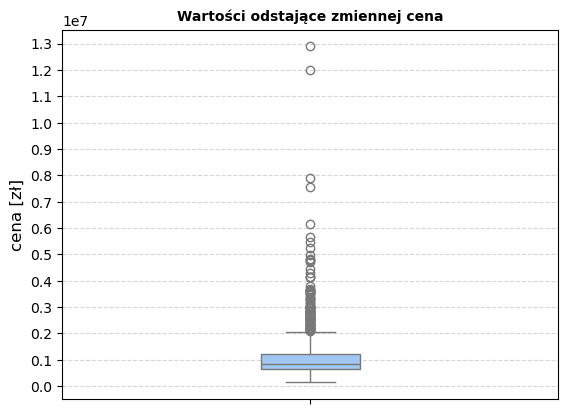

In [12]:
sns.boxplot(y=df["cena"], width=0.2)
plt.title("Wartości odstające zmiennej cena")
plt.yticks([i for i in range(0, 13000001, 1000000)])
plt.ylabel("cena [zł]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Analiza wykresu ukazuje, że typowe ceny mieszkań oscylują wokół 1 mln zł. Górna granica typowych wartości wynosi ok. 2 mln zł. Widoczny jest bardzo długi ogon wartości odstających powyżej górnego wąsa oraz brak występowania wartości poniżej dolnego wąsa. Szczególną uwagę zwracają dwie skrajne wartości rzędu 12 i 13 mln zł. Mogą one wynikać z błędów przy wprowadzaniu danych lub dotyczyć wyjątkowo luksusowych nieruchomości, co zostanie poddane weryfikacji poniżej.

In [13]:
print("Liczba wartości odstających:", df.loc[lower | upper, "cena"].count())
df[lower | upper].sort_values("cena")

Liczba wartości odstających: 108


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
879,2100000,77.18,8.00,NaN,3.00,1.00,4.00,4.52,Warszawa,apartamentowiec,do zamieszkania,drewniane,NaN
1162,2120000,125.25,26.00,1500.00,5.00,1.00,4.00,6.34,Warszawa,apartamentowiec,do zamieszkania,plastikowe,kotłownia
720,2150000,91.30,16.00,1200.00,4.00,2.00,10.00,9.90,Warszawa,blok,do zamieszkania,drewniane,miejskie
220,2150000,125.00,90.00,1500.00,5.00,2.00,2.00,3.35,Warszawa,kamienica,do remontu,plastikowe,miejskie
1026,2150000,91.00,26.00,1300.00,3.00,1.00,6.00,5.19,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,6150000,150.00,8.00,2900.00,5.00,14.00,14.00,1.05,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
995,7550000,207.00,3.00,2500.00,4.00,4.00,4.00,3.91,Warszawa,apartamentowiec,do wykończenia,drewniane,miejskie
341,7900000,342.55,15.00,5500.00,4.00,8.00,8.00,0.89,Warszawa,apartamentowiec,NaN,NaN,miejskie
725,11990000,271.00,5.00,4000.00,7.00,7.00,8.00,1.38,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie


Zgodnie z przypuszczeniami wysnutymi podczas analizy wykresu, skrajnie wysokie ceny obejmują mieszkania o powierzchni w setkach $m^2$, w nowych apartamentowcach, usytuowanych blisko centrum Warszawy. Są to jednak bardzo skrajne wartości i dotyczą zmiennej objaśnianej. Pomimo tego, że wyglądają całkowicie poprawnie, dla dobra modelu i niezaburzania dalszej analizy, postanowiono je usunąć.

In [14]:
df = df.drop(index=[725, 846])

##### **6.2 Powierzchnia**

In [15]:
area_iqr = iqr(df["powierzchnia"])
print(area_iqr[:2])

lower = df["powierzchnia"]<=area_iqr[0]
upper = df["powierzchnia"]>=area_iqr[1]

(np.float64(3.5487500000000054), np.float64(107.75874999999999))


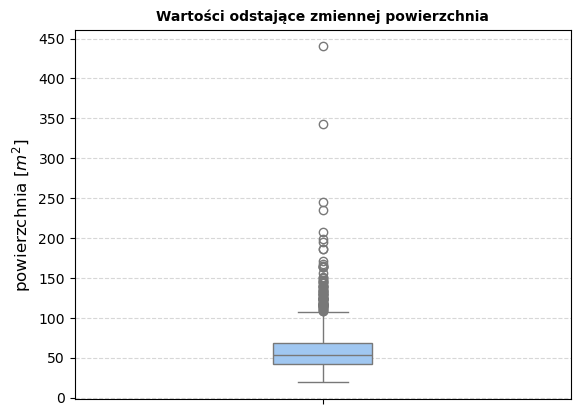

In [16]:
sns.boxplot(y=df["powierzchnia"], width=0.2)
plt.title("Wartości odstające zmiennej powierzchnia")
plt.yticks([i for i in range(0, 500, 50)])
plt.ylabel("powierzchnia [$m^2$]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Typowa powierzchnia mieszkań mieści się w przedziale 40-70 $m^2$. Górna granica typowych wartości sięga lekko ponad 100 $m^2$. Podobnie jak w przypadku cen, widoczny jest wyraźny ogon górnych wartości odstających, przy jednoczesnym braku występowania anomalii poniżej dolnego wąsa. Powierzchnie rzędu kilkuset $m^2$ dotyczą najprawdopodobniej luksusowych apartamentów, co zostanie sprawdzone dokładnie w dalszej analizie.

In [17]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "powierzchnia"].count())
df[lower | upper].sort_values("powierzchnia")

Liczba wartości odstających:  79


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1098,1490000,108.19,30.00,1850.00,4.00,4.00,4.00,6.61,Warszawa,blok,do zamieszkania,plastikowe,miejskie
638,3258000,108.60,22.00,2600.00,3.00,5.00,7.00,3.54,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
636,1810000,109.70,26.00,3200.00,3.00,3.00,11.00,7.89,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
532,865000,111.00,1.00,NaN,5.00,1.00,2.00,14.90,Marki,blok,do wykończenia,plastikowe,inne
282,2900000,111.70,12.00,NaN,4.00,9.00,9.00,3.78,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7550000,207.00,3.00,2500.00,4.00,4.00,4.00,3.91,Warszawa,apartamentowiec,do wykończenia,drewniane,miejskie
1179,5647680,235.32,19.00,2500.00,5.00,3.00,3.00,9.20,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
681,3200000,245.00,17.00,1388.00,5.00,3.00,3.00,10.24,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,gazowe
341,7900000,342.55,15.00,5500.00,4.00,8.00,8.00,0.89,Warszawa,apartamentowiec,NaN,NaN,miejskie


In [18]:
print(round(3522240/440.28, 2))

8000.0


Analiza rekordu o największej powierzchni budzi wątpliwości. Cena na poziomie 3,5 mln zł przekłada się na zaledwie 8000 zł/1$m^2$, co przy lokalizacji oddalonej o 2,5 km od centrum Warszawy jest wartością bardzo niską. Nawet uwzględniając wiek i rodzaj budynku (100-letnia kamienica) oraz stan *do wykończenia*, oferta ta drastycznie odbiega od pozostałych odstających rekordów - dużych, luksusowych mieszkań w nowych apartamentowcach, które osiągają wielokrotnie wyższe ceny. Ze względu na wysokie ryzyko, że rekord ten stanowi błąd w danych lub dotyczy specyficznej formy własności (np. sprzedaży udziałów), postanowiono usunąć go z bazy.

In [19]:
df = df.drop(index=374)

##### **6.3 Wiek**

In [20]:
age_iqr = iqr(df["wiek"])
print(age_iqr[:2])

lower = df["wiek"]<=age_iqr[0]
upper = df["wiek"]>=age_iqr[1]

(np.float64(-59.0), np.float64(125.0))


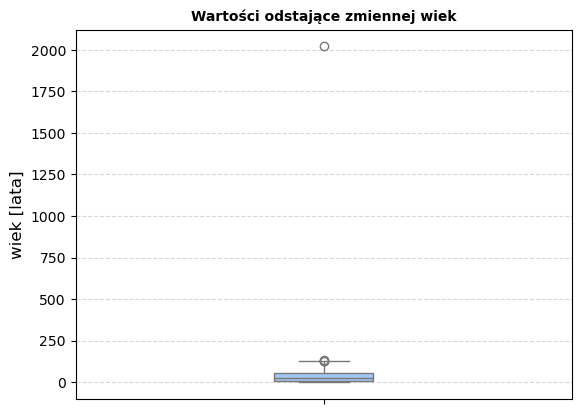

In [21]:
sns.boxplot(y=df["wiek"], width=0.2)
plt.title("Wartości odstające zmiennej wiek")
plt.ylabel("wiek [lata]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Na wykresie wieku budynku widoczna jest jedna, ekstremalna wartość odstająca rzędu 2000 lat. Wynika ona najprawdopodobniej z błędu wprowadzania danych – wiek został omyłkowo wpisany w rok budowy przez autora ogłoszenia. Oprócz tego, tuż powyżej górnego wąsa, występuje skupisko wartości wynoszących nieco ponad 100 lat. Mogą to być autentyczne, przedwojenne kamienice, co zostanie sprawdzone dokładnie poniżej, analizując całe rekordy. Obsrewujemy również brak występowania wartości poniżej dolnego wąsa.

In [22]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "wiek"].count())
df[lower | upper].sort_values("wiek")

Liczba wartości odstających:  6


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1073,1899000,68.00,125.00,700.00,3.00,2.00,6.00,0.99,Warszawa,kamienica,do wykończenia,plastikowe,miejskie
85,799000,46.67,126.00,890.00,2.00,1.00,4.00,1.06,Warszawa,kamienica,NaN,NaN,miejskie
167,1479000,55.00,126.00,720.00,3.00,2.00,5.00,0.66,Warszawa,kamienica,do zamieszkania,plastikowe,miejskie
979,2499000,99.30,126.00,1980.00,4.00,3.00,4.00,1.32,Warszawa,kamienica,do zamieszkania,drewniane,miejskie
598,350000,60.00,136.00,300.00,2.00,2.00,NaN,95.69,Płock,kamienica,do zamieszkania,plastikowe,inne
226,350000,30.00,2021.00,600.00,1.00,1.00,4.00,15.06,Pruszków,blok,do remontu,plastikowe,miejskie


Tak jak było to widoczne na wykresie, rekord o najwyższym wieku budynku ma nierealistyczną wartość 2021 lat. Ze względu na brak możliwości jednoznacznego ustalenia faktycznego wieku tej nieruchomości, wiersz ten zostanie usunięty. Pozostałe wartości odstające (budynki mające 125–136 lat) są wiarygodne - tak jak zakładano dotyczą zabytkowych kamienic.

In [23]:
df = df.drop(index=226)

##### **6.4 Czynsz**

In [24]:
rent_iqr = iqr(df["czynsz"])
print(rent_iqr[:2])

lower = df["czynsz"]<=rent_iqr[0]
upper = df["czynsz"]>=rent_iqr[1]

(np.float64(-7.0), np.float64(1745.0))


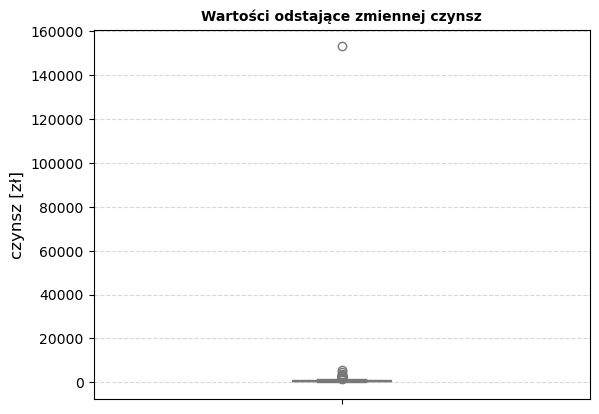

In [25]:
sns.boxplot(y=df["czynsz"], width=0.2)
plt.title("Wartości odstające zmiennej czynsz")
plt.ylabel("czynsz [zł]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Podobnie jak w przypadku poprzedniej zmiennej, analiza wysokości czynszu ukazała jedną, skrajną wartość odstającą wynoszącą ok. 150 tyś. zł, która również najprawdopodobniej wynika z błędu wprowadzenia danych. Niestety drastycznie zaburza ona czytelność całego wykresu. Na ten moment nie stanowi to problemu, ponieważ zgodnie z przyjętym schematem, dla każdej zmiennej nietypowe rekordy są weryfikowane bezpośrednio w ramce danych. 
Ponadto, tutaj również obserwujemy brak występowania wartości poniżej dolnego wąsa.

In [26]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "czynsz"].count())
df[lower | upper].sort_values("czynsz")

Liczba wartości odstających:  54


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1189,2590000,79.60,11.00,1750.00,3.00,1.00,7.00,1.76,Warszawa,apartamentowiec,NaN,NaN,miejskie
551,3650000,146.20,11.00,1760.00,5.00,4.00,4.00,8.98,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
557,1999000,104.08,5.00,1776.00,5.00,4.00,6.00,7.56,Warszawa,blok,do zamieszkania,NaN,miejskie
459,2570000,96.80,11.00,1793.00,3.00,4.00,4.00,8.55,Warszawa,blok,do zamieszkania,drewniane,miejskie
642,2190000,116.00,19.00,1800.00,4.00,3.00,7.00,4.59,Warszawa,blok,do zamieszkania,plastikowe,miejskie
978,2800000,122.00,99.00,1800.00,4.00,4.00,4.00,3.16,Warszawa,kamienica,do zamieszkania,drewniane,inne
1180,3650000,122.00,6.00,1800.00,5.00,4.00,4.00,8.73,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
904,1850000,97.50,10.00,1800.00,4.00,1.00,5.00,6.76,Warszawa,blok,do zamieszkania,plastikowe,miejskie
697,2600000,89.76,10.00,1800.00,4.00,1.00,5.00,1.97,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
481,2990000,81.00,1.00,1800.00,3.00,6.00,28.00,1.61,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie


Omawiany wyżej rekord o najwyższym czynszu na pewno pozostanie usunięty. Pozostałe wartości są realistyczne: dotyczną lokali o powierzchni w setkach $m^2$ w nowoczesnych apartamentowcach albo dotyczną dużych mieszkań w prestiżowych, przedwojennych kamienicach w centrum Warszawy.

In [27]:
df = df.drop(index=813)

##### **6.5 Pokoje**

In [28]:
rooms_iqr = iqr(df["pokoje"])
print(rooms_iqr[:2])

lower = df["pokoje"]<=rooms_iqr[0]
upper = df["pokoje"]>=rooms_iqr[1]

(np.float64(0.5), np.float64(4.5))


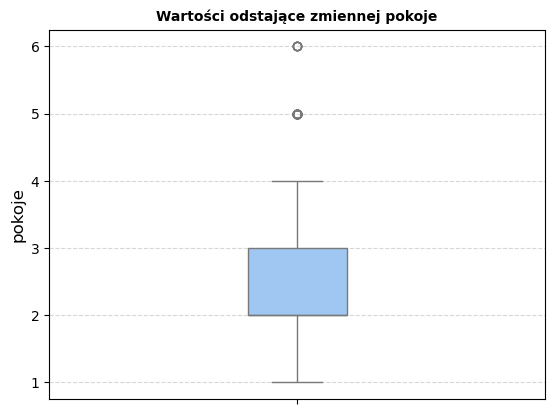

In [29]:
sns.boxplot(y=df["pokoje"], width=0.2)
plt.title("Wartości odstające zmiennej pokoje")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Wykres pokazuje, że typowa liczba pokoi to 2-3. Górna granica standardowych wartości wynosi 4, a dolna 1. Wśród wartości odstających najwięcej jest mieszkań 5-pokojowych, następnie 6-pokojowych, a największa liczba pokoi w analizowanej bazie to 7. Dolne wartości odstające nie występują, co jest w pełni logiczne (brak możliwości wystąpienia nieruchomości o liczbie pokoi mniejszej niż 1).

In [30]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "pokoje"].count())
df[lower | upper].sort_values("pokoje")

Liczba wartości odstających:  39


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
5,1199900,125.20,5.00,NaN,5.00,1.00,2.00,15.03,Kobyłka,apartamentowiec,do zamieszkania,plastikowe,gazowe
585,3590000,135.69,NaN,NaN,5.00,1.00,2.00,5.78,Warszawa,blok,do zamieszkania,drewniane,NaN
619,1450000,67.00,9.00,NaN,5.00,1.00,3.00,2.72,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
664,1450000,97.00,42.00,1580.00,5.00,3.00,3.00,4.51,Warszawa,blok,do remontu,NaN,miejskie
681,3200000,245.00,17.00,1388.00,5.00,3.00,3.00,10.24,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,gazowe
708,2700000,124.05,115.00,NaN,5.00,5.00,6.00,0.84,Warszawa,kamienica,do zamieszkania,NaN,NaN
776,1928000,107.12,14.00,1550.00,5.00,1.00,5.00,7.93,Warszawa,blok,do zamieszkania,drewniane,miejskie
790,2050000,145.58,26.00,NaN,5.00,5.00,6.00,2.58,Warszawa,blok,NaN,plastikowe,miejskie
961,3551360,198.40,30.00,4565.00,5.00,3.00,6.00,7.35,Warszawa,blok,do zamieszkania,drewniane,miejskie
1000,4790000,186.00,114.00,1450.00,5.00,2.00,6.00,1.16,Warszawa,kamienica,do remontu,NaN,miejskie


Wiekszość rekordów o liczbie pokoi powyżej 4 jest wiarygodnych - to mieszkania o dużej powierzchni (100-300$m^2$). Uwagę zwracają jednak ogłoszenia oferujące 5 lub więcej pokoi na metrażu rzędu 50–70 $m^2$. Takie parametry mogą sugerować specyficzne nieruchomości przygotowane pod wynajem, gdzie przestrzeń została maksymalnie podzielona. Aby zweryfikować rynkową zasadność tych danych i ich wpływ na model, przeanalizuję średni metraż przypadającego na jeden pokój.

In [31]:
rooms_outliers = df.loc[[619,527,412,499,916], ["powierzchnia", "pokoje"]]
rooms_outliers["średni metraż"] = rooms_outliers["powierzchnia"] / rooms_outliers["pokoje"]
rooms_outliers

,powierzchnia,pokoje,średni metraż
619,67.00,5.00,13.40
527,67.00,5.00,13.40
412,68.74,5.00,13.75
499,58.10,6.00,9.68
916,63.30,6.00,10.55


Istnieje ryzyko, że w tych rekordach liczba pokoi nie obejmuje kuchni i łazienki. Nawet jeśli to realne oferty pod wynajem, ich skrajnie niski metraż na pokój jest nietypowy dla rynku. Aby nie zaburzać korelacji w modelu i uniknąć błędnych danych, zdecydowano się na ich usunięcie.

In [32]:
df = df.drop(index=[619,527,412,499,916])

##### **6.6 Piętro**

In [33]:
floor_iqr = iqr(df["piętro"])
print(floor_iqr[:2])

lower = df["piętro"]<=floor_iqr[0]
upper = df["piętro"]>=floor_iqr[1]

(np.float64(-3.5), np.float64(8.5))


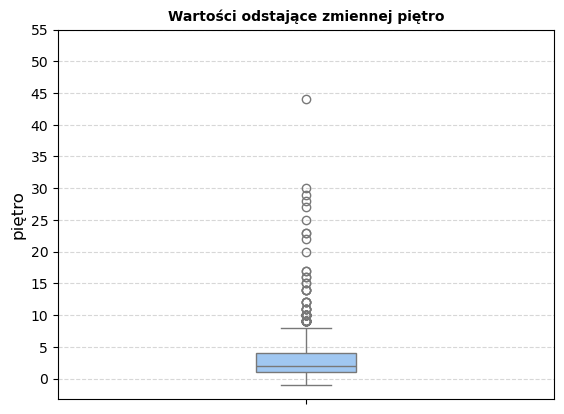

In [34]:
sns.boxplot(y=df["piętro"], width=0.2)
plt.title("Wartości odstające zmiennej piętro")
plt.yticks([i for i in range(0, 60, 5)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Dominująca część mieszkań w bazie znajduje się w niskiej zabudowie - do 4 pięter. Obecne są liczne górne wartości odstające i brak odchyleń w dolnym zakresie. Mimo że metoda IQR wskazuje wartości odstające już od 9. piętra, bloki o wysokości nawet 15–20 pięter są standardem na wielu miejskich osiedlach. Dwie największe wartości (44. i 52. piętro) są całkowicie realne jak na standardy warszawskiego rynku premium, co zostanie dokładnie zweryfikowane poniżej.

In [35]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "piętro"].count())
df[lower | upper].sort_values("piętro")

Liczba wartości odstających:  68


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1237,1249000,88.00,34.00,1400.00,4.00,9.00,10.00,6.23,Warszawa,blok,do zamieszkania,plastikowe,miejskie
900,730000,47.51,52.00,895.00,2.00,9.00,11.00,2.04,Warszawa,blok,do remontu,plastikowe,miejskie
700,550000,42.50,56.00,700.00,2.00,9.00,9.00,6.28,Warszawa,blok,do remontu,plastikowe,miejskie
921,399000,30.00,54.00,650.00,1.00,9.00,10.00,6.35,Warszawa,blok,do remontu,plastikowe,miejskie
932,1390000,76.48,12.00,1112.00,4.00,9.00,10.00,7.08,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,1790000,72.00,3.00,850.00,2.00,27.00,27.00,3.53,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
1035,1297000,35.90,1.00,NaN,1.00,28.00,28.00,1.58,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie
1149,1591000,37.00,2.00,NaN,1.00,29.00,29.00,1.60,Warszawa,apartamentowiec,do zamieszkania,NaN,NaN
987,795000,36.20,21.00,1000.00,1.00,30.00,30.00,1.23,Warszawa,blok,do zamieszkania,plastikowe,miejskie


Tak jak zakładano przy analizie wykresu, mieszkania usytuowane na 30., 40. lub nawet 50. piętrze to apartamenty w nowych, luskusowych wieżowcach mieszkalnych. Dane te są rynkowo poprawne, dlatego zdecydowano się o zachowaniu wszystkich rekordów.

##### **6.7 Liczba pięter budynku**

In [36]:
total_floors_iqr = iqr(df["wysokość budynku"])
print(total_floors_iqr[:2])

lower = df["wysokość budynku"]<=total_floors_iqr[0]
upper = df["wysokość budynku"]>=total_floors_iqr[1]

(np.float64(-2.0), np.float64(14.0))


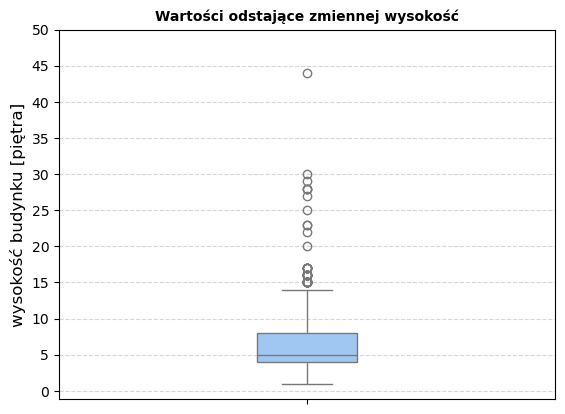

In [37]:
sns.boxplot(df["wysokość budynku"], width=0.2)
plt.title("Wartości odstające zmiennej wysokość")
plt.ylabel("wysokość budynku [piętra]")
plt.yticks([i for i in range(0, 55, 5)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Większość budynków osiąga wysokość rzędu 4-8 pięter. Górna granica typowych wartości to 14 pięter. Widać wiele wartości odstających powyżej górnego wąsa i brak wartości poniżej dolnego wąsa. Analogicznie do zmiennej `piętro`, skrajne wartości rzędu kilkudziesięciu pięter mogą dotyczyć warszawskich apartamentowców, co również zostanie sprawdzone w dalszej analizie.

In [38]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "wysokość budynku"].count())
df[lower | upper].sort_values("wysokość budynku")

Liczba wartości odstających:  57


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
448,770000,36.07,60.00,630.00,2.00,14.00,14.00,1.95,Warszawa,blok,do zamieszkania,plastikowe,inne
1195,6150000,150.00,8.00,2900.00,5.00,14.00,14.00,1.05,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
397,869000,43.50,14.00,900.00,2.00,2.00,14.00,3.49,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
902,950000,54.80,16.00,960.00,2.00,14.00,14.00,6.75,Warszawa,blok,do zamieszkania,drewniane,miejskie
313,1242000,46.00,17.00,NaN,2.00,3.00,14.00,0.59,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
402,4825000,112.24,8.00,NaN,4.00,14.00,14.00,1.02,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie
491,1380000,71.54,17.00,1070.00,2.00,8.00,15.00,7.01,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
595,599000,27.40,54.00,650.00,1.00,15.00,15.00,0.58,Warszawa,blok,do remontu,NaN,miejskie
621,840000,56.80,43.00,857.00,3.00,6.00,15.00,6.27,Warszawa,blok,do zamieszkania,plastikowe,miejskie
623,1288000,73.00,6.00,1500.00,3.00,7.00,15.00,9.99,Warszawa,apartamentowiec,do zamieszkania,plastikowe,NaN


Potwierdza się to samo co w przypadku wartości odstających zmiennej `piętro` - budynki o wysokości 15–20 pięter są standardem, natomiast obiekty w przedziale 20–50 pięter to autentyczne apartamentowce w centrum Warszawy. Tutaj również zdecydowano o zachowaniu wszystkich rekordów.

##### **6.8 Odległość od centrum Warszawy**

In [39]:
distance_iqr = iqr(df["odległość od centrum"])
print(distance_iqr[:2])

lower = df["odległość od centrum"]<=distance_iqr[0]
upper = df["odległość od centrum"]>=distance_iqr[1]

(np.float64(-5.338749999999999), np.float64(19.35125))


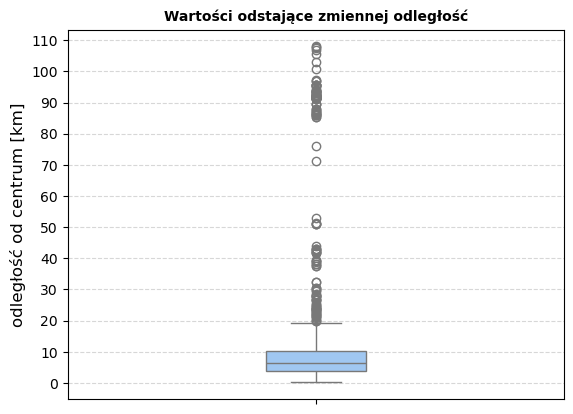

In [40]:
sns.boxplot(df["odległość od centrum"], width=0.2)
plt.title("Wartości odstające zmiennej odległość")
plt.ylabel("odległość od centrum [km]")
plt.yticks([i for i in range(0, 111, 10)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Analiza wykresu pokazuje, że większość mieszkań jest usytuowanych w promieniu do 10 km od centrum Warszawy, co oznacza, że znajdują się one w granicach miasta. Widoczny jest bardzo długi ogon powyżej górnego wąsa, co jest jednak całkowicie uzasadnione, ponieważ analizie poddane są wszystkie nieruchomości w województwie mazowieckim. Brak występowania wartości pod dolnym wąsem (ok. 0 km) jest logiczny, gdyż odległość nie może przyjmować wartości ujemnych.

In [41]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "odległość od centrum"].count())
df[lower | upper].sort_values("odległość od centrum")

Liczba wartości odstających:  132


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
808,450000,46.25,NaN,600.00,3.00,3.00,4.00,19.72,Legionowo,blok,do remontu,plastikowe,miejskie
251,175000,21.00,87.00,170.00,1.00,2.00,2.00,19.98,Wołomin,kamienica,do remontu,plastikowe,elektryczne
483,660000,47.00,20.00,NaN,3.00,1.00,3.00,20.29,Wołomin,blok,do zamieszkania,plastikowe,gazowe
298,650000,55.00,0.00,NaN,2.00,0.00,1.00,20.74,Legionowo,apartamentowiec,do wykończenia,plastikowe,gazowe
300,800000,59.49,6.00,950.00,3.00,4.00,4.00,21.06,Brwinów,blok,do zamieszkania,NaN,inne
...,...,...,...,...,...,...,...,...,...,...,...,...,...
924,409000,72.90,26.00,773.00,3.00,2.00,3.00,105.46,Mława,blok,do zamieszkania,plastikowe,kotłownia
601,459000,60.45,15.00,318.00,4.00,1.00,3.00,106.97,Mława,blok,do zamieszkania,plastikowe,gazowe
494,495000,50.20,2.00,450.00,2.00,4.00,4.00,107.38,Mława,blok,do zamieszkania,plastikowe,gazowe
237,499000,60.64,9.00,NaN,3.00,1.00,4.00,107.73,Mława,blok,do zamieszkania,plastikowe,gazowe


Analiza pełnych rekordów potwierdza wnioski z wykresu - wartości odstające dla odległości od centrum dotyczą lokali położonych poza granicami Warszawy. Ich autentyczność dodatkowo potwierdzają adekwatnie niższe ceny rynkowe. Ponieważ rekordy te są całkowicie poprawne i odzwierciedlają realne zróżnicowanie lokalizacji w zbiorze, jak najbardziej pozostaną one w bazie.

#### **7. Analiza brakujących wartości**

Poniżej przedstawiono zestawienie liczby oraz procentowego udziału brakujących wartości w poszczególnych kolumnach.

In [42]:
missing_vals = df.isnull().sum()
missing_vals_df = pd.DataFrame({"braki":missing_vals})
missing_vals_df["% udział"] = missing_vals_df["braki"]/size * 100
missing_vals_df

,braki,% udział
cena,0,0.00
powierzchnia,0,0.00
wiek,84,6.71
czynsz,211,16.87
pokoje,0,0.00
piętro,10,0.80
wysokość budynku,41,3.28
odległość od centrum,0,0.00
miasto,0,0.00
zabudowa,0,0.00


##### **7.1 Wiek**

Braki w kolumnie `wiek` stanowią niecałe 7% jej zawartości. Zostaną one uzupełnione średnią wartością, z uwzględnieniem podziału na rodzaj zabudowy (o ile wartości te będą się różnić). Istnieje bowiem duże prawdopodobieństwo, że kamienice będą średnio najstarsze, a apartamentowce najmłodsze.

In [43]:
df["wiek"].isnull().sum()

np.int64(84)

In [44]:
grouping = df.groupby("zabudowa")["wiek"]
grouping.mean().round(0)

zabudowa
apartamentowiec   11.00
blok              33.00
kamienica         84.00
Name: wiek, dtype: float64

In [45]:
df["wiek"] = df["wiek"].fillna(grouping.transform("mean").round(0))

In [46]:
df["wiek"].isnull().sum()

np.int64(0)

##### **7.2 Czynsz**

Braki w kolumnie `czynsz` stanowią prawie 17% wartości zmiennej. Aby uzupełnić te dane w sposób logiczny i niezaburzający dalszej analizy, zostaną wykorzystane dostępne dane o powierzchni nieruchomości, zachowując proporcję pomiędzy wielkością mieszkania, a jego kosztami administracyjnymi. Poniżej wyznaczono współczynnik `factor`, reprezentujący średni czynsz na $1 m^2$.

In [47]:
factor = (df["czynsz"]/df["powierzchnia"]).mean()
factor

np.float64(16.004897436922445)

*Factor* wynosi ok. 16 zł za $1 m^2$. 
W kolejnym kroku uzupełnię brakujące wartości w kolumnie *czynsz*, mnożąc ten współczynnik przez powierzchnię danej nieruchomości.

In [48]:
mask = df["czynsz"].isnull()

In [49]:
df.loc[mask, "czynsz"] = df.loc[mask, "powierzchnia"] * factor

In [50]:
mask.isnull().sum()

np.int64(0)

##### **7.3 Piętro**

Braki w kolumnie `piętro` stanowią niespełna 1% wartości zmiennej. Ze względu na znikomy udział, zdecydowano o uzupełnieniu ich medianą, co pozwoli zachować kompletność zbioru bez ryzyka zniekształcenia danych.

In [51]:
floor_median = df["piętro"].median()
floor_median

2.0

In [52]:
df["piętro"] = df["piętro"].fillna(floor_median)

In [53]:
df["piętro"].isnull().sum()

np.int64(0)

##### **7.4 Wysokość budynku**

Braki w kolumnie `wysokość budynku` stanowią lekko ponad 3% wartości zmiennej. Zostaną one uzupełnione średnią wartością tej kolumny dla rodzaju zabudowy. Dodatkowo zostanie wprowadzony jednak warunek korygujący: w przypadkach, gdy przypisana mediana będzie niższa niż wartość w kolumnie `piętro`, wysokość budynku zostanie zrównana z kondygnacją lokalu.

In [54]:
df.loc[df["wysokość budynku"].isnull(), "zabudowa"].value_counts()

zabudowa
blok               29
apartamentowiec     7
kamienica           5
Name: count, dtype: int64

In [55]:
grouping = df.groupby("zabudowa")["wysokość budynku"]
grouping.mean().round(0)

zabudowa
apartamentowiec   7.00
blok              6.00
kamienica         4.00
Name: wysokość budynku, dtype: float64

In [56]:
df["wysokość budynku"] = df["wysokość budynku"].fillna(grouping.transform("mean").round(0))
mask = df["wysokość budynku"] < df["piętro"]
df.loc[mask, "wysokość budynku"] = df.loc[mask, "piętro"]

In [57]:
df["wysokość budynku"].isnull().sum()

np.int64(0)

##### **7.5 Wykończenie**

Braki w kolumnie `wykończenie` stanowią ok. 8% wartości zmiennej. Zostaną one uzupełnione najczęstszą wartością z całego zbioru, czyli modą. Przy tak małym odsetku braków uznano to za w pełni bezpieczne rozwiązanie.

In [58]:
condition_mode = df["wykończenie"].mode()[0]
condition_mode

'do zamieszkania'

In [59]:
df["wykończenie"] = df["wykończenie"].fillna(condition_mode)

In [60]:
df["wykończenie"].isnull().sum()

np.int64(0)

##### **7.6 Okna**

W przypadku zmiennej `okna` braki danych stanowią aż 28% analizowanej zmiennej, więc uzupełnienie ich modą uznano za zbyt ryzykowne rozwiązanie. Poniżej sprawdzono, czy rodzaj okien jest powiązany z wiekiem budynku.

In [61]:
windows_and_age_sorted = df[["wiek", "okna"]].sort_values("wiek")

In [62]:
windows_and_age_sorted.head(200)["okna"].value_counts()

okna
plastikowe    122
drewniane      20
aluminiowe      3
Name: count, dtype: int64

In [63]:
windows_and_age_sorted.tail(200)["okna"].value_counts()

okna
plastikowe    113
drewniane      27
Name: count, dtype: int64

Ze względu na wysoki odsetek braków danych (28%) oraz brak wiarygodnej metody ich estymacji, kolumna `okna` zostanie całkowicie usunięta ze zbioru. Wstępna analiza nie wykazuje wyraźnej zależności między rodzajem okien a wiekiem budynku. W starszych budynkach drewniane okna są masowo wymieniane na plastikowe, podczas gdy w nowych inwestycjach klasy premium często powraca się do okien drewnianych. Chociaż widać, że na rynku dominują okna plastikowe, odgórne uzupełnienie tą wartością blisko jednej trzeciej wartości zmiennej mogłoby sztucznie zniekształcić dane.

In [64]:
df = df.drop("okna", axis=1)

##### **7.7 Ogrzewanie**

Braki danych w kolumnie `ogrzewanie` stanowią zaledwie 6% wartości zmiennej. Podobnie jak w przypadku zmiennej `wykończenie`, zostaną one uzupełnione najczęściej występującą wartością (modą).

In [65]:
heating_mode = df["ogrzewanie"].mode()[0]
heating_mode

'miejskie'

In [66]:
df["ogrzewanie"] = df["ogrzewanie"].fillna(heating_mode)

In [67]:
df["ogrzewanie"].isnull().sum()

np.int64(0)

#### **8. Wizualizacja danych**

Na wstępie zaimportowano dodatkowe biblioteki niezbędne do wizualizacji (część z nich wczytano już w rozdziale 6. przy okazji generowania wykresów pudełkowych). Ponieważ we wcześniejszych krokach usunięto część rekordów, przed przystąpieniem do wizualizacji zreindeksowano cały zbiór danych, a następnie wyświetlono jego zaktualizowane statystyki opisowe.

In [68]:
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

In [69]:
df = df.reset_index(drop=True)
statistics = df.describe()
statistics

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum
count,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00
mean,1086356.36,59.85,33.79,934.19,2.57,3.20,6.14,12.38
std,777706.79,28.36,27.69,470.68,0.92,3.46,3.92,20.46
min,145000.00,19.00,-1.00,1.00,1.00,-1.00,1.00,0.19
25%,659000.00,42.50,11.00,650.00,2.00,1.00,4.00,3.92
50%,849950.00,53.55,26.00,820.00,2.00,2.00,5.00,6.34
75%,1202500.00,68.54,55.25,1088.33,3.00,4.00,8.00,10.09
max,7900000.00,342.55,136.00,5500.00,6.00,44.00,44.00,108.04


##### **8.1 Histogramy dla zmiennych ilościowych**

Na początku zdefiniowana została funkcja usprawniająca wyświetlanie histogramów.

In [70]:
def plots(df, var, f1, f2, **kwargs):
    plt.figure(figsize=(f1,f2))
    ax = sns.histplot(data=df, x=var, **kwargs)
    if ax.lines:
        ax.lines[0].set_color("#416787")
    plt.ylabel("częstość")
    plt.axvline(np.mean(df[var]), color="#D55E00", linewidth=2, linestyle="--", label="średnia")
    plt.axvline(np.median(df[var]), color="#CC0000", linewidth=2, linestyle="--", label="mediana")
    textstr = f"Średnia: {np.mean(df[var]):.2f}\nMediana: {np.median(df[var]):.2f}\nStd: {np.std(df[var]):.2f}"
    ax.text(0.8, 0.98, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='#c8e2ff', alpha=0.8))
    plt.legend(loc="upper right")

###### **8.1.1 Cena**

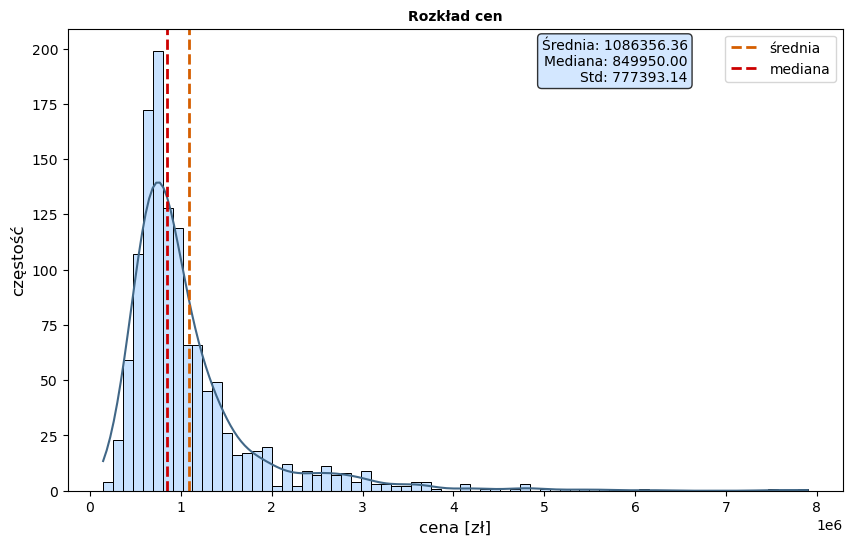

In [71]:
plots(df, "cena", 10, 6, kde=True)
plt.title("Rozkład cen")
plt.xlabel("cena [zł]")
plt.ylabel("częstość")
plt.show()

Rozkład cen jest silnie prawoskośny, co pokazuje, że większość mieszkań z badanego zbioru mieści się w niższych przedziałach cenowych (do ok. 1,2 mln zł). Widoczny długi prawy ogon oznacza, że pojawiają się pojedyncze, wyjątkowo drogie nieruchomości. Mocno zniekształcają one ogólny obraz, ponieważ sztucznie *ciągną* średnią w górę. Można założyć, że gdyby nie te wartości odstające, średnia cena rynkowa byłaby zauważalnie niższa. Z tego względu znacznie lepszą miarą tendencji centralnej – odporniejszą na skrajne odchylenia – jest w tym przypadku mediana, która wynosi 850 tys. zł. Dodatkowo odchylenie standardowe jest bardzo wysokie i stanowi prawie 82% średniej, co wskazuje na zróżnicowanie cen nieruchomości.

###### **8.1.2 Powierzchnia**

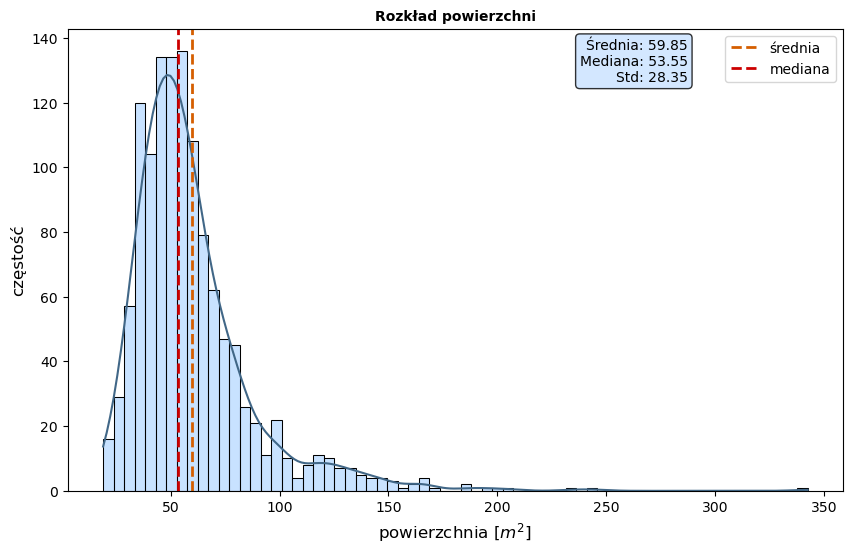

In [72]:
plots(df, "powierzchnia", 10, 6, kde=True)
plt.title("Rozkład powierzchni")
plt.xlabel("powierzchnia [$m^2$]")
plt.ylabel("częstość")
plt.show()

Podobnie jak w przypadku cen, rozkład powierzchni jest silnie prawoskośny. Pokazuje to, że metraż większości mieszkań mieści się w niższych wartościach (w przedziale 30-80 $m^2$). Długi prawy ogon na wykresie oznacza występowanie nielicznych, wyjątkowo dużych mieszkań - najprawdopodobniej luksusowych apartamentów. Analogicznie do poprzedniej zmiennej, te wartości odstające sztucznie zawyżają średnią, jednak nie zniekształca to obrazu tak drastycznie, jak w przypadku cen (różnica między medianą a średnią wynosi ok. 6,5 $m^2$). Odchylenie standardowe jest wysokie i stanowi prawie połowę średniej, co wskazuje na duże zróżnicowanie powierzchni lokali w zbiorze.

###### **8.1.3 Wiek**

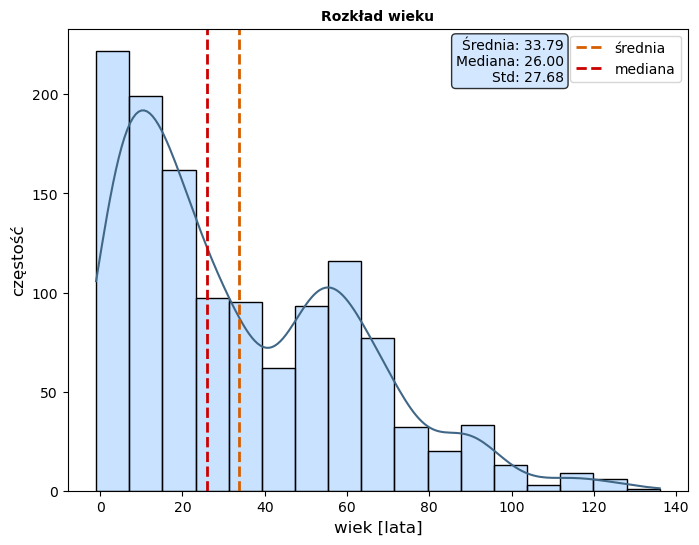

In [73]:
plots(df, "wiek", 8, 6, kde=True)
plt.title("Rozkład wieku")
plt.xlabel("wiek [lata]")
plt.ylabel("częstość")
plt.show()

Rozkład wieku jest prawoskośny. Widzimy, że największą część badanego zbioru stanowią mieszkania stosunkowo młode (do 20 lat). Można jednak zaobserwować dużą grupę budynków wybudowanych 50-70 lat temu. Wykres pokazuje też lekki wzrost w okolicy 90 lat - są to najprawdopodobniej przedwojenne kamienice. Krzywa opada o wiele łagodniej niż w dwóch poprzednich przypadkach, co wskazuje na mniejszą liczbę wartości odstających (pokrywa się to z poprzednią analizą, gdzie zidentyfikowano ich tylko 6). Z tego powodu możemy uznać, że średnia (34 lata) jest bardziej miarodajna niż wcześniej, ale wciąż pozostaje nieco zawyżona względem mediany (26 lat). Odchylenie standardowe jest bardzo wysokie i stanowi prawie 82% średniej, co wskazuje na ogromne zróżnicowanie wieku analizowanych budynków.

###### **8.1.4 Czynsz**

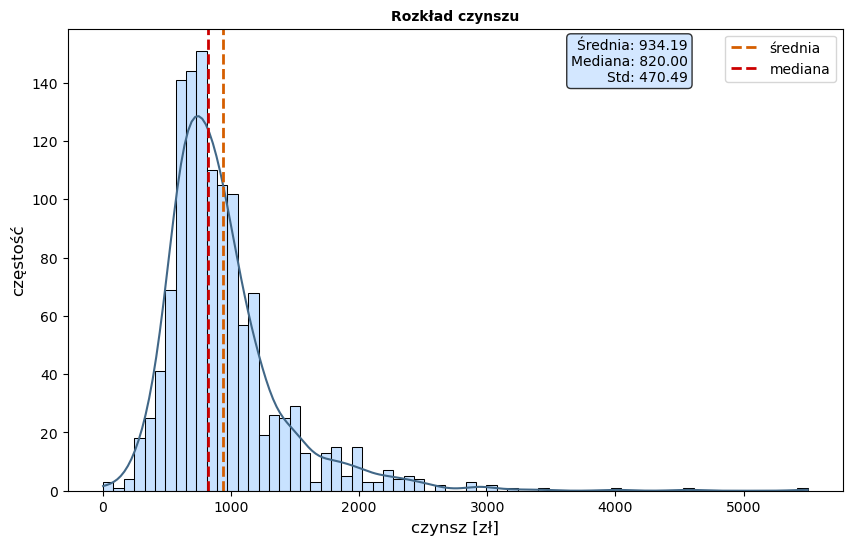

In [74]:
plots(df, "czynsz", 10, 6, kde=True)
plt.title("Rozkład czynszu")
plt.xlabel("czynsz [zł]")
plt.ylabel("częstość")
plt.show()

Rozkład czynszu jest silnie prawoskośny. Widać, że zdecydowana większość opłat administracyjnych mieści się w przedziale 500-1000 zł. Ponownie możemy zauważyć długi prawy ogon, oznaczający pojedyncze nieruchomości o wyjątkowo wysokim czynszu. Wskutek tego średnia jest wyższa od mediany o blisko 120 zł. Choć na rynku zdarzają się niższe opłaty, największe zagęszczenie wartości przypada na przedział 600–800 zł. Odchylenie standardowe stanowi lekko ponad połowę średniej (ok. 51%), co wskazuje na duże zróżnicowanie czynszu w badanym zbiorze.

###### **8.1.5 Pokoje**

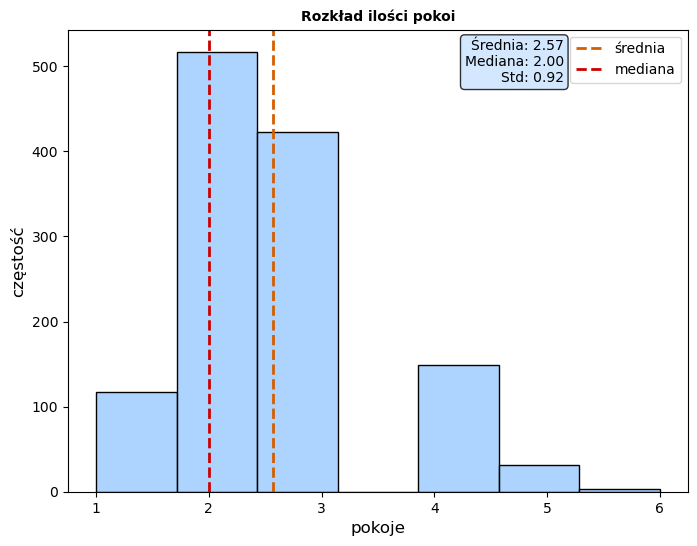

In [75]:
plots(df, "pokoje", 8, 6, bins=7)
plt.title("Rozkład ilości pokoi")
plt.xlabel("pokoje")
plt.ylabel("częstość")
plt.show()

Rozkład ilości pokoi również jest prawoskośny. Nie mamy tutaj jednak bardzo skrajnych wartości odstających - najwyższa zanotowana wartość to 7 pokoi. Średnia (2,58) nadal jest lekko zawyżona względem mediany (2,00), jednak trafnie wskazuje na przedział między 2 a 3 pokojami, co idealnie pokrywa się z największym zagęszczeniem na wykresie. Odchylenie standardowe wynosi niespełna 1 pokój, co stanowi tylko ok. 36% średniej. Pokazuje to, że w przeciwieństwie do pozostałych zmiennych, zróżnicowanie nieruchomości pod względem ilości pokoi nie jest aż tak duże.

###### **8.1.6 Piętro**

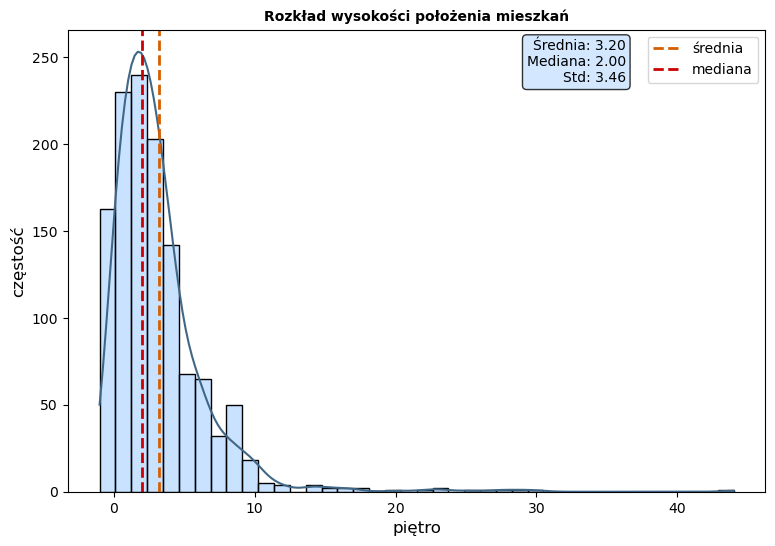

In [76]:
plots(df, "piętro", 9, 6, bins=40, kde=True)
plt.title("Rozkład wysokości położenia mieszkań")
plt.xlabel("piętro")
plt.ylabel("częstość")
plt.show()

Rozkład wysokości położenia mieszkań jest silnie prawoskośny, co pokazuje, że większość lokali mieści się w niższym przedziale (do 10. piętra). W badanym zbiorze dominują nisko położone mieszkania - największe zagęszczenie przypada na wartości od -1. (sutereny) do 4. piętra. Podobnie jak w przypadku innych zmiennych, pojawia się długi prawy ogon, co oznacza rzadkie występowanie bardzo wysoko położonych lokali. Średnia wysokość mieszkania to ok. 3. piętro, a mediana przypada na 2. piętro - różnica między tymi miarami nie jest więc tak drastyczna. Warto jednak zaznaczyć, że odchylenie standardowe jest wyższe od średniej, co potwierdza duże zróżnicowanie położenia nieruchomości w analizowanym zbiorze.

###### **8.1.7 Wysokość budynku**

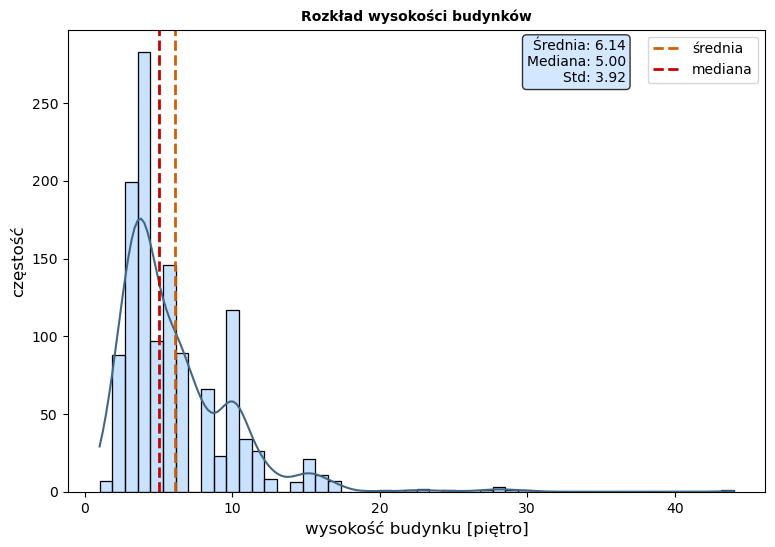

In [77]:
plots(df, "wysokość budynku", 9, 6, bins=50, kde=True)
plt.title("Rozkład wysokości budynków")
plt.xlabel("wysokość budynku [piętro]")
plt.ylabel("częstość")
plt.show()

Bardzo podobnie jak w przypadku wysokości położenia mieszkań, rozkład wysokości całych budynków jest silnie prawoskośny. W badanym zbiorze największe zagęszczenie przypada na niską zabudowę (do 6 pięter), przy czym widać zauważalny spadek liczebności w przypadku budynków 4-piętrowych. Wykres pokazuje również wyraźny, drugi szczyt w okolicach 10 pięter, co odzwierciedla obecność standardowych, wysokich bloków. Analogicznie do poprzedniej zmiennej, długi prawy ogon oznacza występowanie pojedynczych, bardzo wysokich budynków - najprawdopodobniej apartamentowców. Różnica między średnią (6-piętrowce) i medianą (5-piętrowce) jest tutaj niewielka. Odchylenie standardowe stanowi jednak aż 67% wartości średniej, pokazując duże zróżnicowanie wysokości analizowanych budynków.

###### **8.1.8 Odległość od centrum**

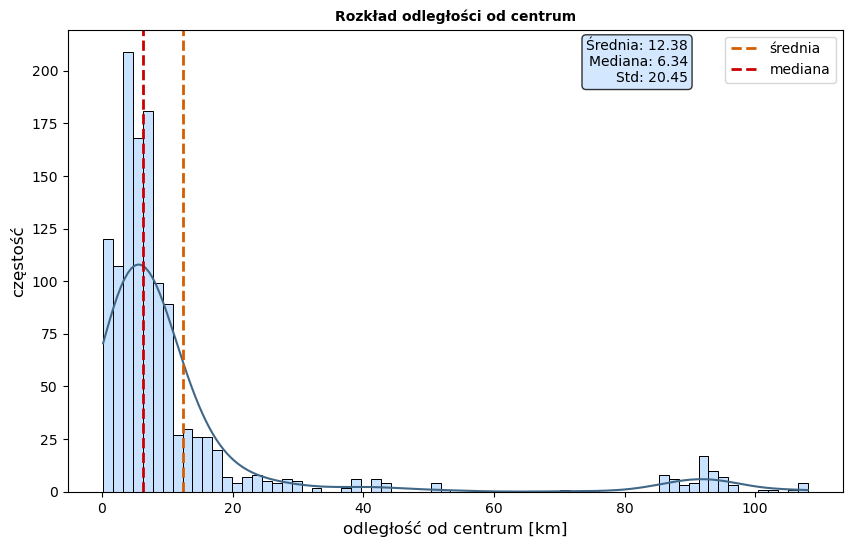

In [78]:
plots(df, "odległość od centrum", 10, 6, kde=True)
plt.title("Rozkład odległości od centrum")
plt.xlabel("odległość od centrum [km]")
plt.ylabel("częstość")
plt.show()

Rozkład odległości od centrum jest również silnie prawoskośny. Widać, że zdecydowana większość lokali mieści się w promieniu 10 km od centrum, czyli w granicach Warszawy. Mniejsza, ale nadal znacząca liczba nieruchomości (z wyraźną tendencją spadkową) roziąga się w przedziale 12-20 km. Dalej można zauważyć nieliczne lokale oddalone do ok. 50 km. Uwagę zwraca wyraźny, ponowny wzrost w okolicach 90 km od centrum Warszawy. Ze względu na te skrajne wartości, średnia (12,4 km) jest mocno zawyżona względem mediany (6,3 km). Odchylenie standardowe stanowi ok. 165% wartości średniej. W przypadku tej zmiennej jest to jednak całkowicie uzasadnione - analizie poddane są nieruchomości w całym województwie mazowieckim.

##### **8.2 Wykresy słupkowe dla zmiennych jakościowych**

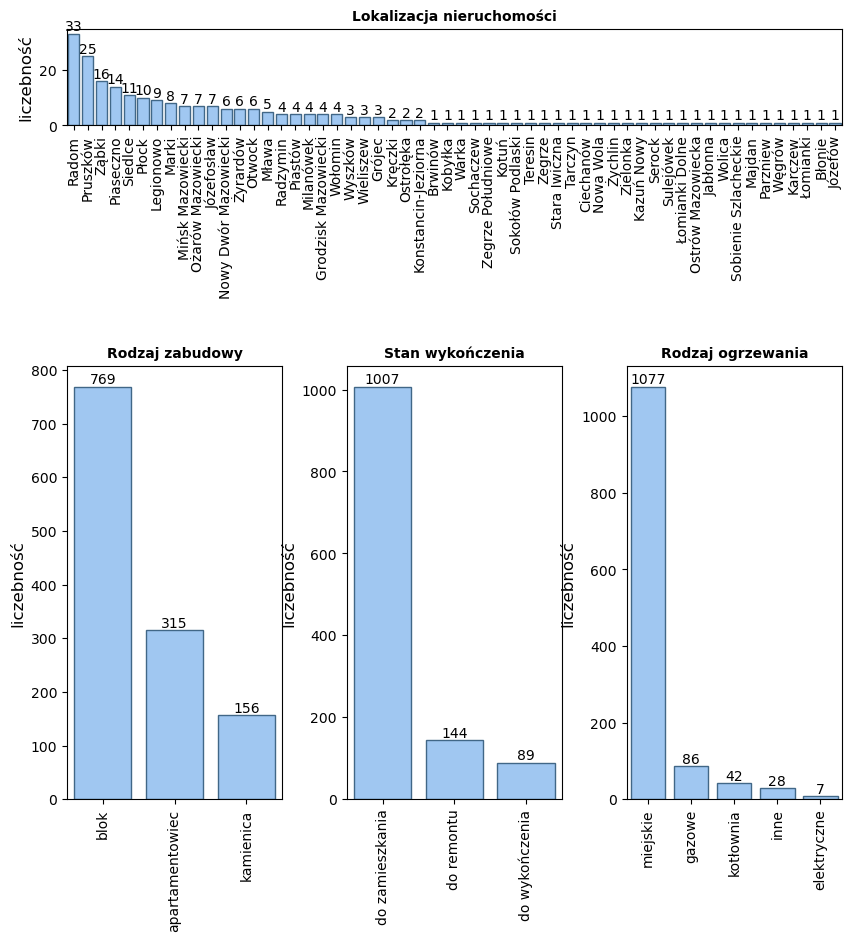

In [79]:
df_temp = df[df["miasto"] != "Warszawa"]
fig = plt.figure(figsize=(10,10))

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=2.5, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1:, 0])
ax3 = fig.add_subplot(gs[1:, 1])
ax4 = fig.add_subplot(gs[1:, 2])

sns.countplot(data=df_temp, x="miasto", order=df_temp["miasto"].value_counts().index, ax=ax1, edgecolor="#416787")
ax1.set_title("Lokalizacja nieruchomości")
ax1.set_xlabel("")
ax1.set_ylabel("liczebność")
ax1.tick_params(axis="x", rotation=90)
for container in ax1.containers:
    ax1.bar_label(container)

sns.countplot(data=df, x="zabudowa", order=df["zabudowa"].value_counts().index, ax=ax2, edgecolor="#416787")
ax2.set_title("Rodzaj zabudowy")
ax2.set_xlabel("")
ax2.set_ylabel("liczebność")
ax2.tick_params(axis="x", rotation=90)
for container in ax2.containers:
    ax2.bar_label(container)

sns.countplot(data=df, x="wykończenie", order=df["wykończenie"].value_counts().index, ax=ax3, edgecolor="#416787")
ax3.set_title("Stan wykończenia")
ax3.set_xlabel("")
ax3.set_ylabel("liczebność")
ax3.tick_params(axis="x", rotation=90)
for container in ax3.containers:
    ax3.bar_label(container)

sns.countplot(data=df, x="ogrzewanie", order=df["ogrzewanie"].value_counts().index, ax=ax4, edgecolor="#416787")
ax4.set_title("Rodzaj ogrzewania")
ax4.set_xlabel("")
ax4.set_ylabel("liczebność")
ax4.tick_params(axis="x", rotation=90)
for container in ax4.containers:
    ax4.bar_label(container)

plt.show()

W zestawieniu lokalizacji celowo pominęto Warszawę, aby uniknąć zaburzenia czytelności wykresu przez jej dominujący udział. 
Najwyższą liczbą ofert wyróżnia się Radom (33 oferty), jako drugie największe miasto na Mazowszu. Tuż za nim odznaczają się miejscowości na obrzeżach stolicy, takie jak Pruszków, Ząbki czy Piaseczno. Na kolejnych miejscach widać inne większe miasta - Siedlce (11) oraz Płock (10). Prawa strona wykresu charakteryzuje się długim, płaskim ogonem, który obrazuje duże rozproszenie geograficzne w bazie (małe miejscowości posiadają po 1-2 rekordy).

Drugi wykres przedstawia strukturę rodzaju zabudowy. Tutaj zdecydowanie dominują bloki (796 ofert), których jest ponad dwukrotnie więcej niż apartamentowców (317). Najmniejszą grupę stanowią kamienice (156), na co wpływ może mieć to, że Warszawa uległa ogromnym zniszczeniom podczas wojny. Widać, że starsze budowle są zastępowane przez nowoczesne apartamentowce.

Analizując przedostatni wykres, można zauważyć, że obecnie na rynku dominują mieszkania gotowe do zamieszkania (1009 ofert). Jest ich aż 7-krotnie więcej od lokali do remontu i ponad 11-krotnie więcej od lokali do wykończenia. Może to sugerować, że wyremontowanie mieszkania przed sprzedażą generuje większy zarobek, niż sprzedawanie mieszkania w stanie deweloperskim/do remontu po niższej cenie. Z drugiej strony, może być to też zasługa zwykłej rotacji, kiedy ludzie sprzedają swoje dotychczasowe, już urządzone mieszkania, decydując się na zakup czegoś nowego.

W przypadku rodzaju ogrzewania widać dominację ogrzewania miejskiego (1079 ofert). Jest to w pełni logiczne, ponieważ przez ostatnie lata odchodzi się od instalacji gazowych na rzecz bezpieczeństwa i wygody, a w budynkach powyżej 25 metrów wysokości są one całkowicie zakazane. Można również zauważyć, że ogrzewanie elektryczne stanowi zaledwie 7 ofert, czego przyczyną mogą być wysokie rachunki za prąd oraz trudność w ogrzaniu całego budynku (wymaga to ogromnej mocy przyłączeniowej).

##### **8.3 Macierz korelacji pomiędzy zmiennymi ilościowymi**

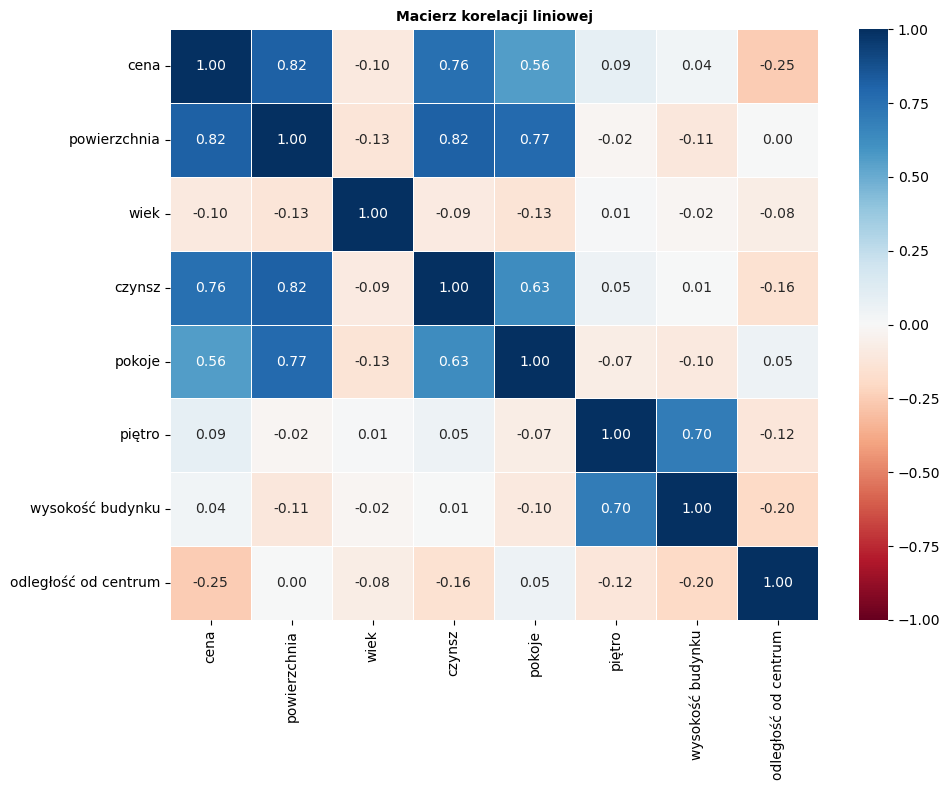

In [80]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1,  linewidths=0.5, linecolor="white", fmt=".2f", cmap="RdBu")
plt.title("Macierz korelacji liniowej")
plt.tight_layout()
plt.show()

Powyższa mapa cieplna obrazuje współczynniki korelacji liniowej Pearsona pomiędzy badanymi zmiennymi. Najsilniejszą, dodatnią korelację w całym zbiorze wykazują powierzchnia lokalu i wysokość czynszu (0.82) oraz powierzchnia lokalu i jego cena (0.82). Dużą współzależność widać również pomiędzy powierzchnią a liczbą pokoi (0.77) i między ceną a czynszem (0.76). Możemy wnioskować, że zbiór danych opiera się na wyraźnym bloku czterech zmiennych: powierzchnia, pokoje, cena i czynsz, które w największym stopniu na siebie oddziałują.

Można zauważyć również silną korelację piętra z wysokością budynku (0.69), która jest jednak naturalna (wysokie piętra występują w wysokich budynkach). W przypadku zmiennej odległości od centrum, jej korelacje z innymi zmiennymi są słabe, a także wykazują ujemny kierunek względem ceny (-0.25) i czynszu (-0.16). Potwierdza to, że im dalej od Śródmieścia, tym koszty zakupu i najmu spadają.

Jeśli chodzi natomiast o korelacje bardzo słabe lub praktycznie niewystępujące, dotyczą one przede wszystkim zmiennej wiek, która nie wykazuje istotnego liniowego związku z żadnym z pozostałych parametrów. Odległość od centrum nie ma żadnego wpływu na wielkość lokalu (korelacja wynosi 0). Z kolei parametry takie jak wysokość budynku czy konkretne piętro, nie wykazują powiązania z wielkością mieszkania i mają niewielki wpływ na jego ostateczną cenę.

##### **8.4 Wykresy zależności między zmiennymi objaśniającymi a zmienną objaśnianą**

###### **8.4.1 Zmienne ilościowe**

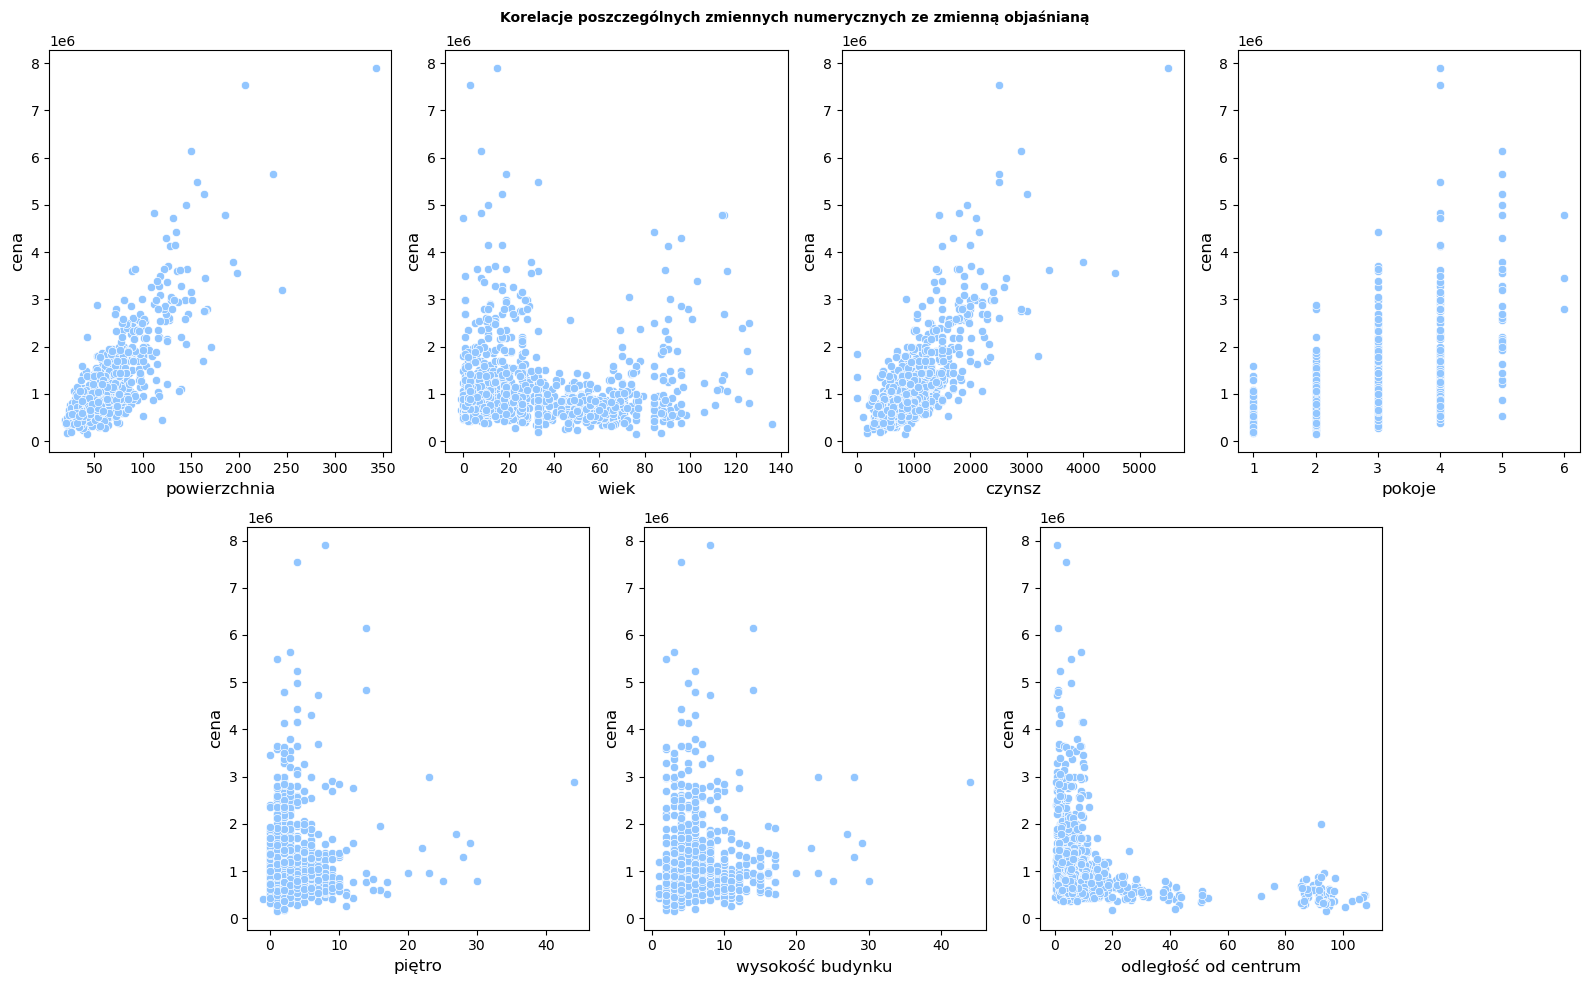

In [81]:
layout = """
AABBCCDD
.EEFFGG.
"""

fig, axes = plt.subplot_mosaic(layout, figsize=(16,10))

keys = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

for i in range(0, 7):
    ax = axes[keys[i]]
    sns.scatterplot(df, x=df.columns[i+1], y="cena", ax=ax)

plt.suptitle("Korelacje poszczególnych zmiennych numerycznych ze zmienną objaśnianą")
plt.tight_layout()

Przede wszystkim widać, że pomiędzy ceną a powierzchnią oraz ceną a czynszem zachodzi wyraźny, dodatni trend liniowy, co pokrywa się z wnioskami wysuniętymi przy analizie mapy cieplnej. Oznacza to, że wraz ze wzrostem tych zmiennych, rośnie też cena nieruchomości.

Zależność między ceną a wiekiem budynku wykazała najmniejszą korelację liniową spośród wszystkich badanych cech. Można jednak zauważyć, że najniższe i najbardziej ujednolicone ceny dotyczą budynków mających około 40–80 lat (prawdopodobnie bloki z czasów PRL). Z kolei największy rozstrzał i wzrost cenowy widać zarówno dla najnowszego budownictwa (nowoczesne apartamentowce) i budynków stuletnich (odrestaurowane, zabytkowe kamienice).

Liczba pokoi jest zmienną dyskretną, która w badanym zbiorze przyjmuje wartości tylko od 1 do 7, z tego powodu wykres układa się w pionowe słupki. Można tu zauważyć dodatni trend przy przechodzeniu z 1 do 3 pokoi, który dalej zanika na rzecz rozrzutu cenowego.

W przypadku relacji ceny z piętrem oraz ceny z wysokością budynku, największe zagęszczenie ofert występuje dla najniżych wartości obu zmiennych. Co ciekawe, widać, że najdroższe nieruchomości znajdują się przeważnie w niższym budownictwie (do ok. 15 pięter). Z kolei na bardzo wysokich piętrach (w wieżowcach) brakuje tanich mieszkań, co pokrywa się z realiami rynkowymi.

Jeśli chodzi o cenę i odległość od centrum, wyraźnie widać nieliniową zależność – początkowo ceny drastycznie spadają w miarę oddalania się od Śródmieścia. Na wykresie widać jednak ponowny, delikatny wzrost wartości w odległości około 80–100 km, co wskazuje na rynki nieruchomości wokół innych, większych miast Mazowsza.

###### **8.4.2 Zmienne jakościowe**

Aby przedstawić ogólny wpływ zmiennych jakościowych na zmienną objaśniającą, zostanie zastosowana skala logarytmiczna dla osi rzędnych. W przypadku zwykłej skali, ekstremalne wartości odstające wymuszają nienaturalne rozciągnięcie osi Y, co zaburza proporcje pudełek i uniemożliwia dokładne odczytanie median. Dla ułatwienia czytelności wykresu zależności ceny od miasta, miejscowości, które posiadają mniej niż 12 ogłoszeń w bazie zgrupowałam w jedną kategorię. Przy okazji będzie to krok niezbędny w uczeniu maszynowym.

In [82]:
counts = df["miasto"].value_counts()
cities = counts[counts < 12].index.tolist()

df.loc[df["miasto"].isin(cities), "miasto"] = "inne"

In [83]:
def boxplots(df, x, i):
    ticks = [200000, 500000, 1000000, 2000000, 5000000, 10000000]
    price_format = ticker.FuncFormatter(lambda x, pos: f"{x/(10**6)}")
    sns.boxplot(df, x=x, y="cena", ax=ax[i], order=df.groupby(x)["cena"].median().sort_values().index)
    ax[i].set_yscale("log")
    ax[i].set_yticks(ticks)
    ax[i].yaxis.set_major_formatter(price_format)
    ax[i].set_ylabel("cena [mln zł]")

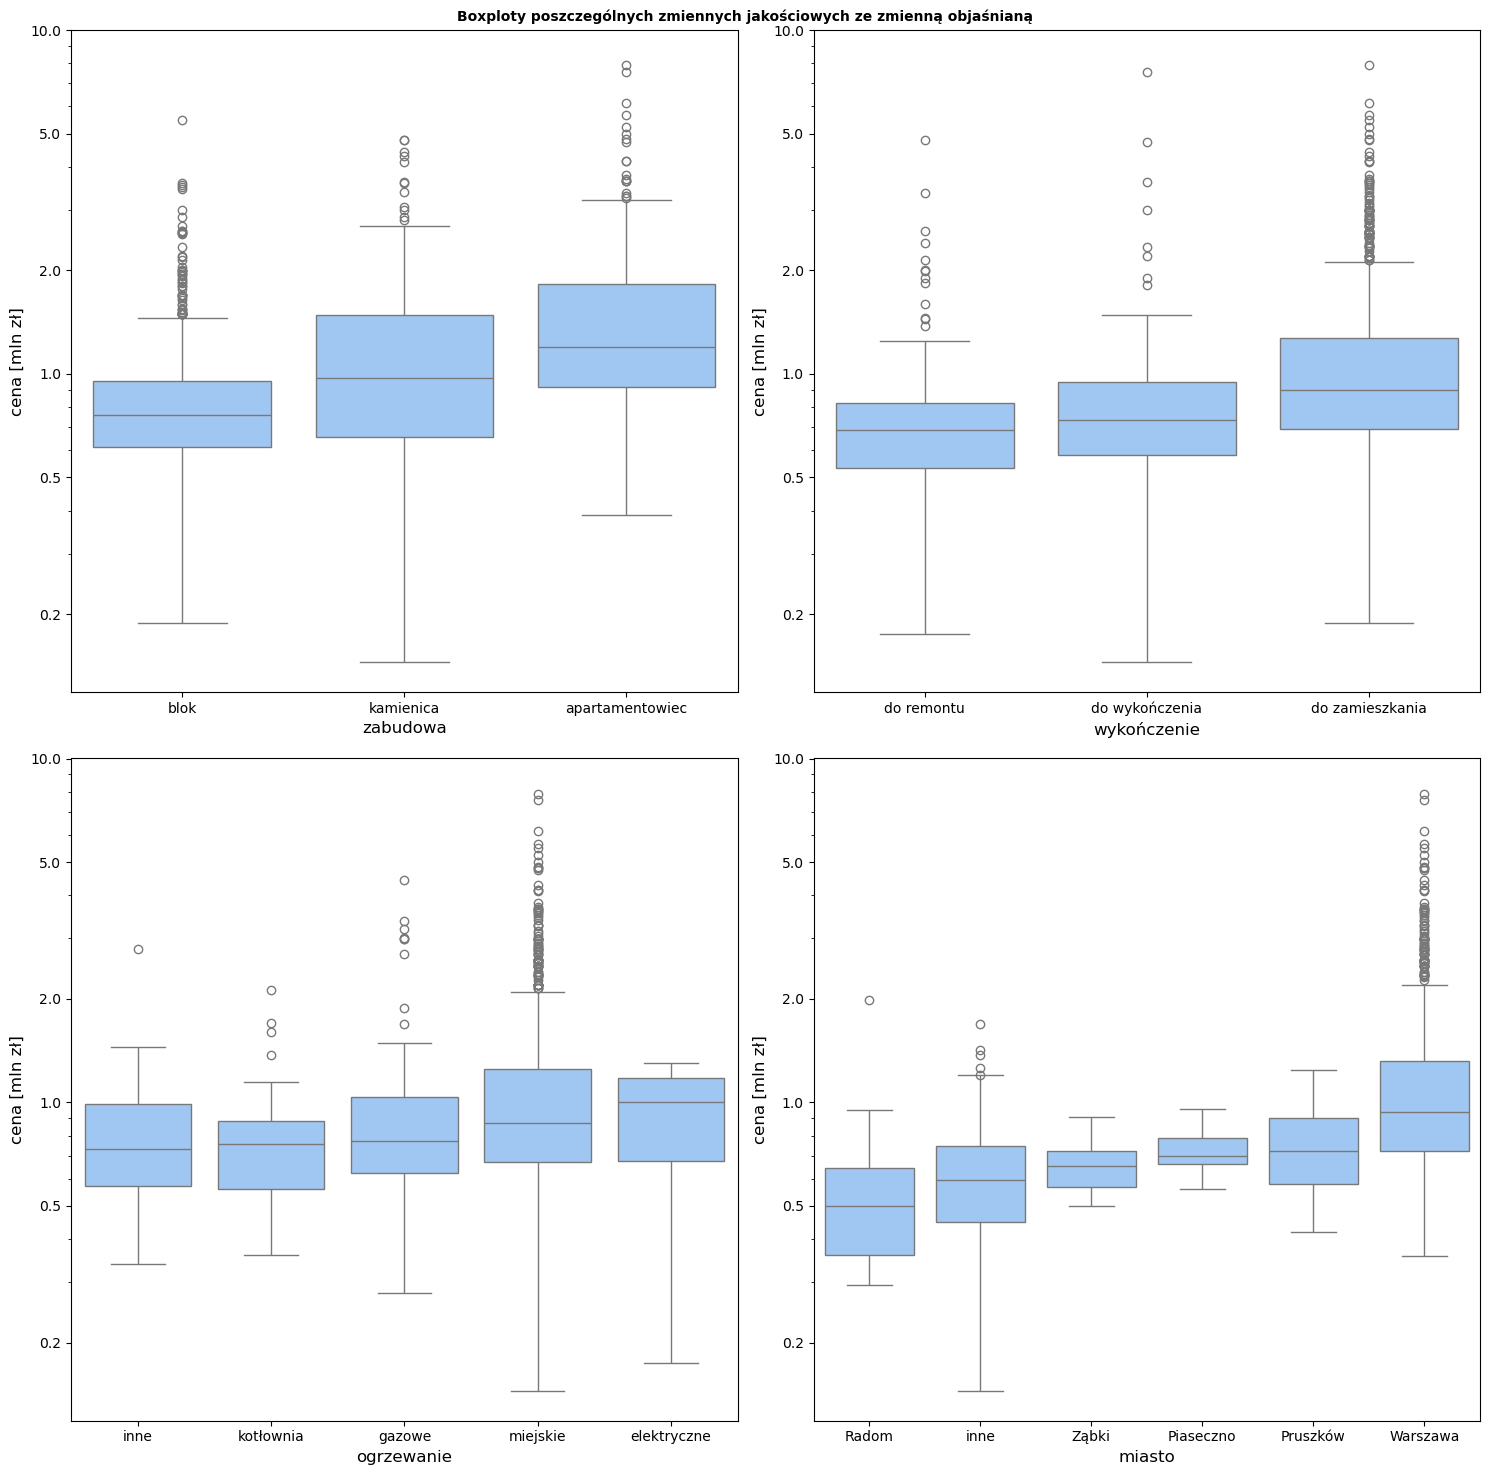

In [84]:
fig, ax = plt.subplots(2, 2, figsize=(15,15))
ax = ax.flatten()

boxplots(df, "zabudowa", 0)
boxplots(df, "wykończenie", 1)
boxplots(df, "ogrzewanie", 2)
boxplots(df, "miasto", 3)

plt.suptitle("Boxploty poszczególnych zmiennych jakościowych ze zmienną objaśnianą")
plt.tight_layout()

Analizując zależność pomiędzy ceną a rodzajem zabudowy widzimy, że mieszkania o najwyższych, odstających cenach to apartamentowce. Ta kategoria charakteryzuje się też najwyższą medianą i największym rozstrzałem cenowym dla typowych ofert. Najtańszą i najstabilniejszą opcją są mieszkania w blokach. Pojawia się tutaj też najwięcej skrajnych wartości, co wynika jednak najprawdopodobniej z największej liczebności ofert. Kamienice znajdują się pośrodku stawki i nie wyróżniają się tak ekstremalnymi wahaniami cen.

W przypadku zależności pomiędzy ceną a stanem wykończenia, najwyższą medianą oraz największym rozstzałem cenowym charakteryzują się lokale gotowe do zamieszkania. Posiadają one również najwięcej wartości odstających oraz są one najbardziej skrajne. Jest to jednak jednocześnie najliczniejsza grupa. Najstabilniejszą cenowo opcją są mieszkania do remontu, które cechują się najniższą medianą. Lokale do wykończenia wykazują również podobną stabilność i niewiele wyższe ceny.

Jeśli chodzi o przedostatni wykres, widzimy, że mieszkania o najwyższych, skrajnie odstających cenach korzystają z ogrzewania miejskiego. Charakteryzuje się one również największą liczbą wartości skrajnych i dużym rozstrzałem cenowym. Ponownie jednak możemy to uzasadnić tym, że jest to najliczniejsza kategoria. Co ciekawe, pomimo, że ogrzewanie elektyczne było najmniej liczną grupą, cechuje się ono sporym rozstrzałem cenowym i ma wyższą medianę niż mieszkania z ogrzewaniem miejskim. Z kolei nieruchomości ogrzewane za pomocą kotłowni charakteryzują się najmniejszym rozstrzałem cenowym.

Na wykresie widać, że Warszawa dominuje pod względem mediany i rozstrzału cen, a także posiada najwięcej wartości odstających i są one najbardziej skrajne. Ciekawym zjawiskiem jest fakt, że Radom, jako drugie największe miasto na Mazowszu (oraz druga najliczniejsza kategoria), ma najniższą medianę cen i ustępuje pod tym względem o wiele mniejszym miejscowościom na obrzerzch stolicy. 

Wpływ rodzaju zabudowy na cenę jest znaczący - widać tutaj wyraźny skok mediany o ok. 0,4 mln zł, a same pudełka przesuwają się w górę i słabo na siebie nachodzą. Stan wykończenia ma o wiele mniejszy wpływ na ogólną cenę - mediana i wielkość dwóch pierwszych grup są bardzo zbliżone, jedynie kategoria *do zamieszkania* jest trochę droższa. Zmienna ogrzewanie również słabo tłumaczy zmienność ceny - mediany (z niewielkim skokiem w przypadku ogrzewania elektrycznego) i wysokości pudełek wszystkich pięciu grup są niemal identyczne. Natomiast jeśli chodzi o wpływ miasta na cenę, jest on bardziej znaczący - widać wzrost mediany od Radomia do Warszawy prawie o 0,5 mln zł, a same pudełka przesuwają się w górę i na siebie nie nachodzą.

##### **8.5 Wykresy pairplot dla najważniejszych zmiennych**

Na wykresie *pairplot* zestawiłam cenę z wybranymi zmiennymi objaśniającymi. Wybrałam powierzchnię, ponieważ wykazała ona najsilniejszą korelację liniową ze zmienną objaśnianą. Uwzględniłam również liczbę pokoi, ponieważ jako zmienna dyskretna pozwala spojrzeć na rozkład danych z innej perspektywy. Dodałam również odległość od centrum, ponieważ wykazała dla ceny ujemną, nielinową korelację. Wszystkie obserwacje zgrupowałam kolorystycznie względem rodzaju zabudowy.

<Figure size 3000x3000 with 0 Axes>

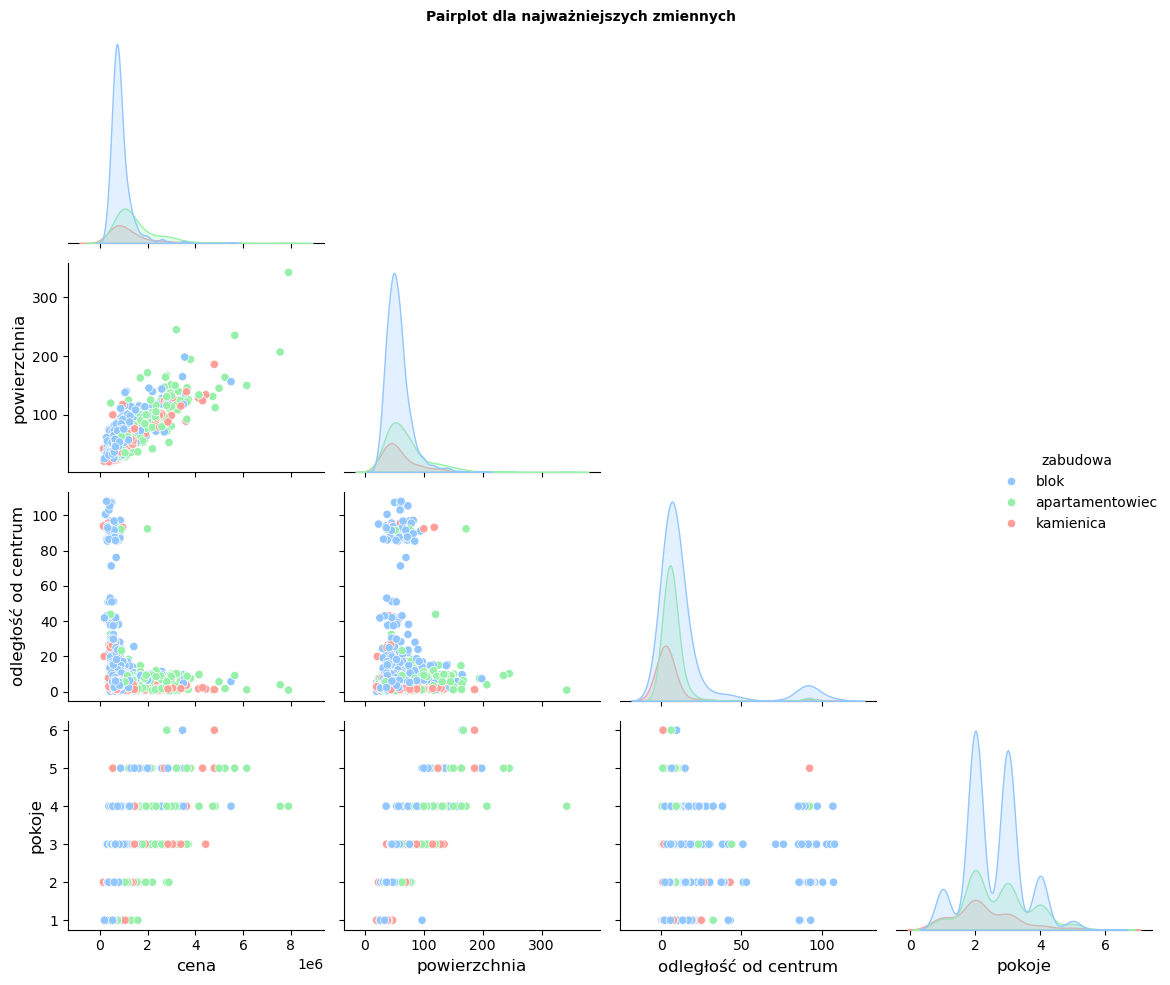

In [85]:
plt.figure(figsize=(30,30))
sns.pairplot(df, hue="zabudowa", vars=["cena","powierzchnia", "odległość od centrum", "pokoje"], height=2.5, corner=True)
plt.suptitle("Pairplot dla najważniejszych zmiennych", fontweight="bold")
plt.tight_layout()
plt.show()

Na początku warto przyjrzeć się diagonali wykresu. Dla każdego wykresu zdecydowanie dominują bloki, co nie jest jednak zaskoczeniem, ponieważ jest to najliczniejsza grupa w zbiorze. Warto zwrócić uwagę, że w przypadku odległości od centrum, w promieniu 80-100 km, czyli w większych mazowieckich miastach, kamienice i apartamentowce praktycznie znikają z rynku. Z kolei w przypadku liczby pokoi standardem są lokale pokojowe.

Na wykresie odległości od centrum i powierzchni widzimy, że nieruchomości mocno oddalone od Warszawy są stosunkowo nieduże i osiągają wielkości do $100m^2$. 

Zależności między liczbą pokoi a ceną oraz liczbą pokoi a powierzchnią wyglądają bardzo podobnie. Dokładna analiza punktów pokazuje jednak, że na rynku można znaleźć nieco tańsze mieszkania pięciopokojowe, które względem samej powierzchni wciąż pozostają bardzo duże. 

Z kolei patrząc na relację liczby pokoi i odległości od Warszawy, widać, że w dalszych rejonach Mazowsza buduje się lokale maksymalnie czteropokojowe.

#### **9. Przetwarzanie danych**

##### **9.1 Import bibliotek oraz podział na zbiór treningowy i testowy**

Na wstępie zaimportowano biblioteki niezbędne do uczenia maszynowego oraz podzielono zbiór danych, wyodrębniając cenę jako zmienną objaśnianą.

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from xgboost import XGBRegressor

In [87]:
X_train, X_test, Y_train, Y_test = train_test_split(df.drop(columns=["cena"]), df["cena"], test_size=0.2, random_state=42)

##### **9.2 Tworzenie własnych transformatorów**

###### **9.2.1 Imputacja danych**

In [88]:
class GroupMeanImputer(BaseEstimator, TransformerMixin, OneToOneFeatureMixin):
    def __init__(self, groupby_col, target_cols):
        self.groupby_col = groupby_col
        self.target_cols = target_cols
        self.means_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.means_ = X_df.groupby(by=self.groupby_col)[self.target_cols].mean().round(0)
        
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
    
        for col in self.target_cols:
            mean_fit = X_df[self.groupby_col].map(self.means_[col])
            X_df[col] = X_df[col].fillna(mean_fit)
    
        return X_df[self.target_cols]

class ProportionalImputer(BaseEstimator, TransformerMixin, OneToOneFeatureMixin):
    def __init__(self, target_col, reference_col):
        self.target_col = target_col
        self.reference_col = reference_col
        self.factor = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        ratio = X_df[self.target_col] / X_df[self.reference_col].replace(0, np.nan)
        self.factor = ratio.mean()
        
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        mask = X_df[self.target_col].isnull()
        X_df.loc[mask, self.target_col] = X_df.loc[mask, self.reference_col] * self.factor

        return X_df[self.target_col]

class HeightImputer(BaseEstimator, TransformerMixin, OneToOneFeatureMixin):
    def __init__(self, groupby_col, target_col, floor_col):
        self.groupby_col = groupby_col
        self.target_col = target_col
        self.floor_col = floor_col
        self.means_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.means_ = X_df.groupby(self.groupby_col)[self.target_col].mean().round(0)
        
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        
        missing_mask = X_df[self.target_col].isnull()
        mapped_means = X_df[self.groupby_col].map(self.means_)
        X_df.loc[missing_mask, self.target_col] = mapped_means[missing_mask]
        correction_mask = X_df[self.target_col] < X_df[self.floor_col]
        
        X_df.loc[correction_mask, self.target_col] = X_df.loc[correction_mask, self.floor_col]
        
        return X_df[self.target_col]

class CityFromDistanceImputer(BaseEstimator, TransformerMixin, OneToOneFeatureMixin):
    def __init__(self, target_col, dist_col, limit, inside_val, outside_val):
        self.target_col = target_col
        self.dist_col = dist_col
        self.limit = limit
        self.inside_val = inside_val
        self.outside_val = outside_val

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        
        missing_mask = X_df[self.target_col].isnull()
        
        mask_inside = missing_mask & (X_df[self.dist_col] <= self.limit)
        X_df.loc[mask_inside, self.target_col] = self.inside_val
        
        still_missing = X_df[self.target_col].isnull() 
        X_df.loc[still_missing, self.target_col] = self.outside_val
        
        return X_df[self.target_col]

Transformator `GroupMeanImputer` służy do wstawiania wartości na podstawie średniej w konkretnych grupach. Sprawdza się to przy kolumnie z wiekiem budynku, ponieważ występuje tam rozstrzał między starymi kamienicami a nowymi apartamentowcami. Drugi transformator `ProportionalImputer` został stworzony z myślą o brakach danych w czynszach, które są silnie uzależnione od powierzchni i w taki sam sposób były uzupełniane w rozdziale 7. `HeightImputer` to specyficzny transformator, który sprawdza czy uzupełniona wartość wysokości budynku jest większa lub równa piętru, na którym dany lokal się znajduje. Transformator wstawia odpowiednią średnią, ale jeśli wyjdzie ona mniejsza niż piętro mieszkania, automatycznie koryguje ten błąd. Natomist transformator `CityFromDistanceImputer` służy do przypisywania wartości "Warszawa", jeśli odległość od centrum nie przekracza 15 km, a w przeciwnym razie automatycznie kategoryzuje miasto jako "inne".

###### **9.2.2 Grupowanie pojedynczych wartości**

In [89]:
class RareCategoryEncoder(BaseEstimator, TransformerMixin, OneToOneFeatureMixin):
    def __init__(self, target_col, min_freq, fill_value="inne"):
        self.target_col = target_col
        self.min_freq = min_freq
        self.fill_value = fill_value
        self.frequent_categories_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        counts = X_df[self.target_col].value_counts()
        self.frequent_categories_ = counts[counts >= self.min_freq].index.tolist()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        mask = ~X_df[self.target_col].isin(self.frequent_categories_)
        X_df.loc[mask, self.target_col] = self.fill_value
        return X_df

Transformator `RareCategoryEncoder` zlicza wystąpienia w zbiorze treningowym i wrzuca wszystkie lokalizacje poniżej określonego progu do kategorii "inne". Dzięki temu zapobiega się przeuczaniu modelu na pojedynczych, niereprezentatywnych przypadkach oraz chroni dane przed rozrostem wymiarowości przy ich późniejszym kodowaniu. Co ważne, transformator wyłapuje i obsługuje też nowe miejscowości, które mogą pojawić się dopiero w przyszłości.

###### **9.2.3 Feature engeenering**

In [90]:
class RatioFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self, new_column_name):
        self.new_column_name = new_column_name
            
    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        self.feature_names_in_ = X.columns
        return self
        
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names_in_[:X.shape[1]])
            
        X_output = X.copy()
        
        c1 = X_output.iloc[:, 0]
        c2 = X_output.iloc[:, 1]
        X_output[self.new_column_name] = c1 / c2.replace(0, 1)
        return X_output
            
        
    def get_feature_names_out(self, input_features=None):
        if input_features:
            return list(input_features) + [self.new_column_name]
        return list(self.feature_names_in_) + [self.new_column_name]      

Transformator `RatioFeatureCreator` służy do "wyciągania" ukrytych relacji między zmiennymi. Wykorzystany zostanie między innymi do obliczenia średniego metrażu przypadającego na jeden pokój, co pozwoli modelowi zidentyfikować standard i przeznaczenie nieruchomości – na przykład odróżnić przestronne mieszkania premium od gęsto podzielonych, małych pokoi inwestycyjnych przeznaczonych pod wynajem.

##### **9.3 Tworzenie i demonstracja pipeline'u**

In [91]:
base_imputation_preprocessor = ColumnTransformer(
    transformers=[
        ("base_categories", 
         SimpleImputer(strategy="most_frequent"), 
         ["zabudowa"]),
        ("base_floor", 
         SimpleImputer(strategy="median"), 
         ["piętro"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

Na początku upewniono się, że uzupełnione zostaną braki w zmiennych referencyjnych. Zmienna `zabudowa` jest konieczna jako klucz grupowania dla transformatora `GroupMeanImputer` oraz transformatora `HeightImputer`, które na jej podstawie estymują wiek i wysokość budynku. Do prawidłowego działania transformatora `HeightImputer`, potrzebne są również pełne dane w zmiennej `piętro`, ponieważ algorytm używa piętra lokalu jako dolnej granicy przy określaniu całkowitej wysokości budynku. W przypadku `ProportionalImputer` niezbędny jest metraż lokalu, jednak z racji wagi tej cechy, potraktowano ją jako zmienną krytyczną i założono brak pustych wartości na wejściu.

In [92]:
main_imputation_preprocessor = ColumnTransformer(
    transformers = [
        ("age_imputation",
         GroupMeanImputer("zabudowa", ["wiek"]),
         ["zabudowa", "wiek"]),

        ("rent_imputation",
         ProportionalImputer("czynsz", "powierzchnia"),
         ["czynsz", "powierzchnia"]),

        ("height_imputation",
         HeightImputer("zabudowa", "wysokość budynku", "piętro"),
         ["zabudowa", "wysokość budynku", "piętro"]),

        ("simple_cat",
         SimpleImputer(strategy="most_frequent"),
         ["wykończenie", "ogrzewanie"]),

        ("simple_num",
         SimpleImputer(strategy="median"),
         ["pokoje"]),
        
        ("keep_references", 
         "passthrough", 
         ["powierzchnia", "zabudowa", "piętro"])
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

Na głównym etapie imputacji uzupełniono braki danych przy użyciu przygotowanych wcześniej transformatorów oraz standardowych metod: mody dla zmiennych kategorycznych oraz mediany dla zmiennych numerycznych.

In [93]:
distance_imputation_preprocessor = ColumnTransformer(
    transformers=[
        ("distance_imputation",
         KNNImputer(n_neighbors=5),
         ["odległość od centrum"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

city_imputation_preprocessor = ColumnTransformer(
    transformers=[
        ("city_imputation",
         CityFromDistanceImputer("miasto", "odległość od centrum", 15, "Warszawa", "inne"),
         ["miasto", "odległość od centrum"]),

        ("keep_references",
         "passthrough",
         ["odległość od centrum"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

W kolejnym kroku uzupełniono braki w zmiennej `odległość od centrum` przy użyciu algorytmu k-najbliższych sąsiadów (KNN). Etap ten realizowany jest dopiero po głównej imputacji, ponieważ (jak wykazano w rozdziale 8.) najwyższą korelacją z odległością charakteryzują się zmienne wysokość budynku oraz czynsz, które musiały zostać wcześniej uzupełnione. Następnie wykorzystano tak przygotowaną kolumnę do estymacji braków w zmiennej `miasto`, co ma zapobiec błędnemu zaklasyfikowaniu jako "Warszawa" nieruchomości znacznie od niej oddalonych.

In [94]:
rare_categories_preprocessor = ColumnTransformer(
    transformers=[
        ("city_encoder",
         RareCategoryEncoder("miasto", min_freq=15),
         ["miasto"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

W kolejnym etapie przetwarzania zredukowano rzadkie kategorii dla zmiennej `miasto`. Miejscowości występujące w zbiorze danych ze zbyt małą częstotliwością (poniżej ustalonego progu) zostaną zgrupowane w zbiorczą kategorię "inne".

In [95]:
feature_engineering_preprocessor = ColumnTransformer(
    transformers=[
        ("feature_eng_1",
         RatioFeatureCreator("powierzchnia na pokój"),
         ["powierzchnia", "pokoje"]),

        ("feature_eng_2",
         RatioFeatureCreator("piętro na wysokość"),
         ["piętro", "wysokość budynku"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False)

Na etapie feature engineeringu wprowadzono dwie nowe zmienne, które mają pozwolić lepiej uchwycić specyfikę ofert. Najpierw wyliczono średnią powierzchnię przypadającą na jeden pokój, dzięki czemu można łatwo ocenić przestronność lokalu i odróżnić ciaśniejsze mieszkania od tych bardziej komfortowych. Druga zmienna to względna wysokość, czyli podzielenie kondygnacji mieszkania przez całkowitą liczbę pięter w budynku. Daje to wynik w czytelnej skali od 0 do 1 i pozwala ocenić realne położenie lokalu – np. 3. piętro w 5-piętrowym bloku ma zupełnie inny charakter niż 3. piętro w 15-piętrowym wieżowcu.

In [96]:
scaling_preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         RobustScaler(),
         make_column_selector(dtype_include=np.number))
    ],
    remainder='passthrough',
    verbose_feature_names_out=False)

encoding_preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(sparse_output=False),
         make_column_selector(dtype_include=object))
    ],
    remainder='passthrough',
    verbose_feature_names_out=False)

W ostatnim kroku przygotowano ostateczną postać zmiennych dla modelu. Wszystkie kolumny numeryczne zostały przeskalowane za pomocą `RobustScaler`, ponieważ w omawianym zbiorze danych wystąpiło wiele wartości odstających – ten skaler jest na nie znacznie bardziej odporny niż standardowe metody. Z kolei w przypadku cech kategorycznych wybrano `OneHotEncoder`, co gwarantuje, że model nie zinterpretuje różnych kategorii w sposób uporządkowany i nie przypisze im sztucznej hierarchii ani wag.

In [97]:
pipe = Pipeline([
    ("base_imputation", base_imputation_preprocessor),
    ("main_imputation", main_imputation_preprocessor),
    ("distance_imputation", distance_imputation_preprocessor),
    ("city_imputation", city_imputation_preprocessor),
    ("rare_categories", rare_categories_preprocessor),
    ("feature_eng", feature_engineering_preprocessor),
    ("scaling", scaling_preprocessor),
    ("encoding", encoding_preprocessor),
    ("model", "passthrough")
]).set_output(transform="pandas")  

In [98]:
pipe.fit(X_train, Y_train)
X_test_processed = pipe.transform(X_test)

X_test_processed.head()

,miasto_Pruszków,miasto_Radom,miasto_Warszawa,miasto_Ząbki,miasto_inne,wykończenie_do remontu,wykończenie_do wykończenia,wykończenie_do zamieszkania,ogrzewanie_elektryczne,ogrzewanie_gazowe,...,zabudowa_kamienica,powierzchnia,pokoje,powierzchnia na pokój,piętro,wysokość budynku,piętro na wysokość,odległość od centrum,wiek,czynsz
415,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.00,-0.39,0.00,-0.09,0.00,-0.25,0.00,-0.21,0.07,-0.52
259,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,...,0.00,0.44,0.00,1.48,0.33,-0.50,0.90,0.20,-0.33,-0.09
332,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.00,-0.89,-1.00,1.19,0.67,0.25,0.30,-0.70,-0.42,-0.09
622,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,...,0.00,1.07,1.00,0.69,0.33,-0.50,0.90,1.52,-0.47,0.21
101,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.00,-0.37,0.00,-0.06,1.33,2.50,-0.18,-0.05,0.44,-0.26


In [99]:
print(f"Kształt danych przed: {X_test.shape}")
print(f"Kształt danych po: {X_test_processed.shape}")

Kształt danych przed: (248, 11)
Kształt danych po: (248, 25)


W wyniku działania utworzonego pipeline'u, wymiarowość zbioru testowego wzrosła z początkowych 11 do 25. Różnica wynosząca dokładnie 14 nowych kolumn jest w pełni oczekiwana:

Stan początkowy: 11 zmiennych.

Kodowanie zmiennej `miasto` (OHE): Zamiana 1 kolumny na 5 kolumn binarnych. (Bilans: 15 kolumn).

Kodowanie zmiennej `wykończenie` (OHE): Zamiana 1 kolumny na 3 kolumny binarne. (Bilans: 17 kolumn).

Kodowanie zmiennej `ogrzewanie` (OHE): Zamiana 1 kolumny na 5 kolumn binarnych. (Bilans: 21 kolumn).

Kodowanie zmiennej `zabudowa` (OHE): Zamiana 1 kolumny na 3 kolumny binarne. (Bilans: 23 kolumny).

Feature Engineering: Stworzenie i dodanie dwóch nowych zmiennych. (Bilans: 25 kolumn).

Powyższe wyliczenia potwierdzają, że transformatory kategoryczne (OHE) oraz inżynieria cech zadziałały bezbłędnie.

Możemy zauważyć, że kolumny o zmiennych jakościowych zawierają same 0 i 1, jak oczekiwano przy użyciu `OHE`. Jeśli chodzi o działanie `RobustScaler`, wartości w kolumnach nie odzwierciedlają już rzeczywistych miar i zostały sprowadzone do niewielkich ułamków. Ponadto w kolumnie `pokoje` dominują wartości 0.00. Oznacza to, że w tych obserwacjach oryginalna liczba pokoi była dokładnie równa medianie wyliczonej ze zbioru treningowego, a wartości -1.00 i 1.00 stanowią odchylenia. Taki regularny rozkład jest w pełni oczekiwany, ponieważ mówimy o zmiennej skokowej z wąskiego przedziału [1; 7].

#### **10. Budowa modelu**

##### **10.1 Import bibliotek oraz porównanie modeli**

Początkowo zaimportowano wszystkie niezbędne biblioteki.

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

Zestawienie modeli dobrano tak, aby przetestować różne podejścia matematyczne. Regresja Liniowa (Linear Regression) służy do sprawdzenia prostej, liniowej korelacji z ceną oraz sprawdzenia, czy wprowadzanie bardziej skomplikowanych algorytmów ma w ogóle sens. Drzewo Decyzyjne (Decision Tree) wprowadza do analizy podejście oparte na nieliniowych regułach warunkowych. XGBoost Regressor to model oparty na wzmacnianiu gradientowym, dodany w celu maksymalizacji dokładności predykcji. Sekwencyjnie poprawia błędy poprzednich drzew, dzięki czemu radzi sobie ze złożonymi i nieliniowymi danymi.

In [101]:
chosen_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=40),
    "XGBoost": XGBRegressor(random_state=40)
}
pipes = {}

for name, model in chosen_models.items():
    print(f"Model: {name}")
    
    test_pipeline = clone(pipe)
    test_pipeline.steps[-1] = ("model", model)
    test_pipeline.fit(X_train, Y_train)
    y_pred = test_pipeline.predict(X_test)

    pipes[name] = test_pipeline

    test_pipeline_wo_fe = clone(pipe)
    test_pipeline_wo_fe.steps[-1] = ("model", clone(model))
    test_pipeline_wo_fe.set_params(feature_eng="passthrough") 
    test_pipeline_wo_fe.fit(X_train, Y_train)
    y_pred_wo_fe = test_pipeline_wo_fe.predict(X_test)
    
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    mae_wo_fe = mean_absolute_error(Y_test, y_pred_wo_fe)
    r2_wo_fe = r2_score(Y_test, y_pred_wo_fe)

    print("Statystyki: ")
    print(f"\tMean Absolute Error (MAE): {mae:.2f}")
    print(f"\tR2 Score: {r2:.4f}")
    print("Statystyki z wyłączeniem feature engeeneringu: ")
    print(f"\tMean Absolute Error (MAE): {mae_wo_fe:.2f}")
    print(f"\tR2 Score: {r2_wo_fe:.4f}\n")

Model: Linear Regression
Statystyki: 
	Mean Absolute Error (MAE): 201853.21
	R2 Score: 0.8079
Statystyki z wyłączeniem feature engeeneringu: 
	Mean Absolute Error (MAE): 199259.02
	R2 Score: 0.8127

Model: Decision Tree
Statystyki: 
	Mean Absolute Error (MAE): 233384.79
	R2 Score: 0.6194
Statystyki z wyłączeniem feature engeeneringu: 
	Mean Absolute Error (MAE): 229955.50
	R2 Score: 0.6262

Model: XGBoost
Statystyki: 
	Mean Absolute Error (MAE): 167731.30
	R2 Score: 0.8318
Statystyki z wyłączeniem feature engeeneringu: 
	Mean Absolute Error (MAE): 178898.66
	R2 Score: 0.8010



"Zwycięzcą" zestawienia okazał się XGBoost, który osiągnął najwyższy współczynnik $R^2$ oraz najniższy MAE. Najsłabiej w obu tych metrykach zaprezentowało się natomiast drzewo decyzyjne. Warto również zaznaczyć, że wdrożenie feature engineeringu wyraźnie poprawiło predykcje w modelach drzewiastych, choć w minimalnym stopniu osłabiło skuteczność regresji liniowej. Przy okazji w każdej iteracji zachowano poszczególne pipeline'y, aby później móc je optymalizować, nie powtarzając kodu.

##### **10.2 Optymalizacja hiperparametrów**

W kolejnym kroku przeprowadzona zostanie optymalizacja hiperparametrów, używając metody algorytmów GridSearchCV (czyli wraz z użyciem walidacji krzyżowej), aby poprawić skuteczności i stabilności wybranych modeli.

In [102]:
searching_configuration = {
    "Linear Regression": {
        "model": pipes["Linear Regression"],
        "parameters": {
            'model__fit_intercept': [True, False],
            'model__positive': [False, True]
        }
    },
    "Decision Tree": {
        "model": pipes["Decision Tree"],
        "parameters": {
            'model__max_depth': [4, 6, 8, 10, 12],
            'model__min_samples_split': [2, 5, 8, 10],
            'model__min_samples_leaf': [1, 2, 4]
        }
    },
    "XGBoost": {
        "model": pipes["XGBoost"],
        "parameters": {
            'model__n_estimators': [200, 300, 500, 800],
            'model__learning_rate': [0.01, 0.02, 0.05],
            'model__max_depth': [4, 5, 6, 8]
        }
    }, 
}

pipes_best_params = {}

for name, settings in searching_configuration.items():
    grid_pipe_xgb = GridSearchCV(
        estimator=settings["model"],
        param_grid=settings["parameters"],
        cv=5,
        n_jobs=-1,
        scoring="neg_mean_absolute_error"
    )
    
    grid_pipe_xgb.fit(X_train, Y_train)
    pipes_best_params[name] = grid_pipe_xgb.best_estimator_
    print(f"Najlepsze parametry dla modelu {name}: {grid_pipe_xgb.best_params_}")

Najlepsze parametry dla modelu Linear Regression: {'model__fit_intercept': True, 'model__positive': False}
Najlepsze parametry dla modelu Decision Tree: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Najlepsze parametry dla modelu XGBoost: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}


Dzięki powyższemu algorytmowi wydobyto najlepsze parametry optymializacyjne dla poszczególnych modeli. Dodatkowo w każdej iteracji zachowano zoptymalizowane pipeline'y, aby w dalszych etapach uniknąć powtarzania kodu.

##### **10.3 Porównanie wyników**

W tej części analizy zestawione zostaną metryki typowe dla problemów regresji. Należą do nich: MSE (średni błąd kwadratowy), RMSE (pierwiastek średniego błędu kwadratowego, który ułatwia interpretację dzięki sprowadzeniu błędu z powrotem do oryginalnych jednostek), MAE i MAPE (czyli średni błąd bezwzględny wyrażony odpowiednio w wartościach liczbowych oraz w procentach), a także $R^2$ (współczynnik determinacji), określający, w jakim stopniu nasz model potrafi prawidłowo wyjaśnić zmienność cen mieszkań.

In [103]:
def show_statistics(pipes):
    results = []
    
    for name, pipe in pipes.items():
        y_pred = pipe.predict(X_test)
    
        mse = mean_squared_error(Y_test, y_pred)
        rmse = root_mean_squared_error(Y_test, y_pred)
        mae = mean_absolute_error(Y_test, y_pred)
        mape = mean_absolute_percentage_error(Y_test, y_pred) * 100
        r2 = r2_score(Y_test, y_pred)
    
        results.append({
            "Model": name,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2
        })
    
    return pd.DataFrame(results)

In [104]:
pd.options.display.float_format = '{:.3f}'.format

In [105]:
df_before = show_statistics(pipes).set_index('Model')
df_after = show_statistics(pipes_best_params).set_index('Model')

In [106]:
df_before

,MSE,RMSE,MAE,MAPE,R2
Model,,,,,
Linear Regression,86035582054.789,293318.227,201853.214,20.019,0.808
Decision Tree,170420903926.818,412820.668,233384.792,19.750,0.619
XGBoost,75317624832.000,274440.562,167731.297,14.597,0.832


In [107]:
df_after

,MSE,RMSE,MAE,MAPE,R2
Model,,,,,
Linear Regression,86035582054.789,293318.227,201853.214,20.019,0.808
Decision Tree,169532320431.303,411743.027,230111.308,19.476,0.621
XGBoost,72834424832.000,269878.531,160616.062,13.984,0.837


W przypadku Regresji Liniowej optymalizacja hiperparametrów nie przyniosła zmian, co jest zrozumiałe, ponieważ algorytm GridSearchCV zachował parametry domyślne. Z kolei dla pozostałych modeli zaobserwować można poprawę wyników: współczynnik $R^2$ wzrósł o 0,002 dla Drzewa Decyzyjnego oraz o 0,005 dla modelu XGBoost. Zwiększyła się również precyzja - średni błąd procentowy (MAPE) spadł o blisko 0,3 pp. dla Drzewa Decyzyjnego i o około 0,6 pp. dla XGBoost.

Najlepiej radzącym sobie algorytmem jest zoptymalizowany model XGBoost. Jego metryka MAE wynosi około 160 tys. zł, co oznacza, że estymacje modelu różnią się od rzeczywistych cen transakcyjnych średnio o 160 tysięcy złotych (średnia cena w badanym zbiorze wynosiła prawie 1,1 mln zł). Biorąc pod uwagę dużą rozpiętość cen w tym regionie, przekłada się to na średni błąd na poziomie 13,98% (MAPE). Warto również zwrócić uwagę na różnicę między metrykami RMSE a MAE. Błąd RMSE wynosi w tym przypadku prawie 270 tys. zł i jest wyraźnie wyższy od błędu bezwzględnego. Pokazuje to, że model czasami popełnia bardzo duże pomyłki w pojedynczych przypadkach. Jest to najprawdopodobniej spowodowane obecnością nietypowych, bardzo drogich nieruchomości, których ceny trudno precyzyjnie przewidzieć.

#### **11. Wyniki i wnioski**

Na podstawie porównania statystyk zaprezentowanych w rozdziale 10.3, najlepszym modelem predykcyjnym okazał się zoptymalizowany algorytm XGBoost.

##### **11.1 Analiza błędów modelu**

In [108]:
y_predict = pipes_best_params["XGBoost"].predict(X_test)
df_results = X_test.copy()

df_results["rzeczywista cena"] = Y_test 
df_results["przewidywana cena"] = y_predict
df_results["MAPE"] = (np.abs(df_results["przewidywana cena"] - df_results["rzeczywista cena"]) / df_results["rzeczywista cena"]) * 100
df_sorted = df_results.sort_values(by="MAPE")

In [109]:
df_sorted.head(8)

,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,ogrzewanie,rzeczywista cena,przewidywana cena,MAPE
1191,41.790,54.000,850.000,2.000,3.000,10.000,6.880,Warszawa,blok,do zamieszkania,miejskie,680000,681165.375,0.171
174,46.400,51.000,680.000,3.000,10.000,10.000,7.880,Warszawa,blok,do zamieszkania,miejskie,680000,677971.438,0.298
312,46.000,17.000,736.225,2.000,3.000,14.000,0.590,Warszawa,apartamentowiec,do zamieszkania,miejskie,1242000,1248858.375,0.552
147,48.420,67.000,950.000,2.000,1.000,4.000,3.920,Warszawa,kamienica,do zamieszkania,miejskie,895000,890023.875,0.556
1228,115.000,103.000,1500.000,3.000,3.000,8.000,1.740,Warszawa,kamienica,do zamieszkania,miejskie,3390000,3408894.750,0.557
168,103.400,26.000,1.000,4.000,0.000,6.000,4.020,Warszawa,blok,do remontu,miejskie,1840000,1826246.125,0.747
666,61.710,8.000,830.000,3.000,2.000,4.000,8.510,Warszawa,apartamentowiec,do zamieszkania,miejskie,1141635,1132885.750,0.766
1213,58.000,10.000,600.000,3.000,0.000,3.000,87.620,inne,blok,do zamieszkania,miejskie,610000,605065.938,0.809


In [110]:
df_sorted.tail(8)

,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,ogrzewanie,rzeczywista cena,przewidywana cena,MAPE
542,59.000,77.000,900.000,2.000,2.000,3.000,2.050,Warszawa,kamienica,do zamieszkania,miejskie,839000,1231647.375,46.799
199,44.180,96.000,707.096,2.000,1.000,2.000,26.500,inne,kamienica,do wykończenia,kotłownia,384700,567181.375,47.435
630,109.700,26.000,3200.000,3.000,3.000,11.000,7.890,Warszawa,apartamentowiec,do zamieszkania,miejskie,1810000,2703881.750,49.386
76,72.500,6.000,1160.355,4.000,3.000,5.000,5.750,Warszawa,apartamentowiec,do zamieszkania,miejskie,989000,1477459.125,49.389
976,36.200,21.000,1000.000,1.000,30.000,30.000,1.230,Warszawa,blok,do zamieszkania,miejskie,795000,1213061.750,52.586
772,56.000,111.000,750.000,2.000,4.000,4.000,2.390,Warszawa,kamienica,do remontu,miejskie,769000,1206411.750,56.881
618,167.000,9.000,2000.000,6.000,8.000,8.000,6.270,Warszawa,apartamentowiec,do zamieszkania,miejskie,2800000,4698797.500,67.814
44,68.000,33.000,1100.000,3.000,5.000,5.000,1.390,Warszawa,blok,do zamieszkania,miejskie,798000,1598991.125,100.375


Analizując tabelę najgorszych predykcji można zauważyć, że model przeszacowuje ceny w najgorszych przypadkach. Widzimy tutaj, że najgorsze predykcje dotyczą mieszkań, które mają jakieś *skrajne* cechy, z którymi model rzadko się spotyka. Na przykład:
- mieszkanie o indeksie 976 - 30. piętro w 30-piętrowym budynku. Ma ono tylko 36$m^2$ i jest bardzo blisko centrum. Model prawdopodobnie uznał je za luksusowy apartament i wycenił na 1,2 mln zł, podczas gdy naprawdę kosztowało 795 tys. zł,
- lokale o indeksach 630 i 618 - czynsze wynoszą tam kolejno 3200 zł i 2000 zł, co dla modelu również mogło być sygnałem, żeby podnieść cenę (w tym zbiorze czynsz był mocno, liniowo skorelowany z ceną).

Dodatkowo możemy spekulować, że rynek kamienic jest trudny do przewidzenia - w grupie najgorszych predykcji mamy aż 3 kamienice o wieku 77, 96 i 111 lat. Wynika to najprawdopodobniej z tego, że w zbiorze występowały zarówno kamienice tanie do generalnego remontu, jak i luksusowe, odrestaurowane o wysokim, historycznym prestiżu.

Natomiast z analizy tabeli najlepszych wyników, widzimy, że model bardzo dobrze radzi sobie ze standardowymi mieszkaniami. Nawet jeśli pojawia się tam droga nieruchomość (np. kamienica za 3,39 mln zł pod indeksem 1228), to ma ona bardzo racjonalny zestaw cech (duża powierzchnia, 3 pokoje, 3. piętro).

##### **11.2 Wnioski z analizy oraz potencjalne kierunki rozwoju**

Głównym ograniczeniem obecnego modelu jest jego wysoka wrażliwość na wartości skrajne. Największe problemy występują z nieruchomościami o nietypowych parametrach - wysokie czynsze w tys. zł, najwyższe piętra wieżowców, wiekowe, historyczne kamienice.

Aby w przyszłości zoptymalizować model, najlepszym rozwiązaniem byłoby zawężenie jego działania. Przykładowo: usunięcie z danych treningowych skrajnych obserwacji, szczególnie cen oraz czynszów oraz skupienie się wyłącznie na standardowym budownictwie (bloki), pomijając drapacze chmur oraz kamienice.

Oczywiście zawsze można też wzbogacić model o bardziej precyzyjne cechy (np. odległość od najbliższej stacji metra lub rok przeprowadzenia generalnego remontu).

##### **11.2 Podsumowanie**

Reasumując, powyższy projekt udowadnia, że algorytmy uczenia maszynowego stanowią bardzo skuteczne narzędzie do szacowania cen nieruchomości na Mazowszu, pod warunkiem odpowiedniego zdefiniowania grupy docelowej. Stworzony estymator może nie sprawdzić się najlepiej przy wycenach unikalnych, luksusowych apartamentów w centrum stolicy, jednak może w przyszłości się stać dobrym narzędziem wspierającym sektor prywatny. Model może służyć do sprawdzania opłacalności oferty dla mniejszych, prywatnych deweloperów, lokalnych inwestorów czy zwykłych rodzin szukających mieszkania. Pozwala on dość trafnie oszacować, czy cena standardowego lokalu w bloku nie jest sztucznie zawyżona przez sprzedającego, a z drugiej strony – pomaga samym właścicielom w rzetelnej wycenie własnej nieruchomości przed wystawieniem jej na rynek.